In [1]:
# =============================================================================
# Which errors do they make in the FLUENCY zone? The same 5 multiplications
# =============================================================================
# QUESTION: the same histograms as error_types.ipynb (A998), but on Fluency zone
# data, so the errors can be read without the A998 correction artefact.
#
# WHY ONE HISTOGRAM PER ATTEMPT IS ENOUGH HERE ------------------------------
# In A998 the histograms are split in two because the app corrects keystroke by
# keystroke: if the first digit already makes the product impossible, the answer
# is submitted on its own and gets recorded half-typed (Decision #11). The
# Fluency zone is a different app -- Leitner-style cards, two attempts per card,
# no timer -- and does NOT behave that way. The three checks are re-run on live
# data in the next cell, but the numbers are:
#   . of the ONE-digit wrong answers to two-digit products, 63.9% ARE the
#     correct tens digit (over all facts; over these 5 and the 1st attempt only
#     it is ~48%). In A998 it was 1.06% (a ~16x gap). Here nothing is sent until
#     the pupil sends it, so the digit typed first is exactly what is recorded.
#   . median duration: 4.93 s for a correct 1st attempt, 10.02 s for a wrong
#     one. Errors are SLOWER than correct answers, the opposite of A998 (4.20 s
#     correct against 1.40-1.63 s wrong, i.e. immediate rejection).
#   . there is no 66/67/76/77 block (Decision #12): the most frequent wrong
#     answers to the 5 facts are 54, 56, 42, 24, 45, 64, 46, 36 -- all
#     arithmetic, all between 7.6 and 10 s. No typing population to separate.
# So every numeric answer goes on the SAME axis, and no speed-sitting flag is
# needed.
#
# THE TWO ATTEMPTS, AND WHICH ONE IS DRAWN ---------------------------------
#   1st attempt: the spontaneous answer (every card that is not 'Correct at
#          first'). Colour = whether it was recovered at the 2nd attempt. This
#          is the only attempt that gets drawn (FIG A).
#   2nd attempt: only cards that ended 'Incorrect', so by construction
#          everything there is "failed both". Its figure (FIG B) was dropped on
#          2026-08-12: attempt 2 now survives only in the tables below.
#
# WHICH 5 FACTS: the same as A998 (4x8, 5x8, 6x8, 7x8, 8x8), because the point
# is to compare the SAME operation across the two apps. Where they really sit
# within Fluency is what the fluency_rank / fluency_error_pct columns say, and
# those are computed over ALL facts: 6x8 is 5th (39.6%), 7x8 6th (39.3%), 8x8
# 7th (39.3%), but 4x8 13th (30.8%) and 5x8 29th (19.3%).
# CAREFUL: Fluency also drills tables 10, 11 and 12, which A998 does not have,
# and those dominate its difficulty (12x12 62.5%, 11x11 59.7%, 11x12 58.0%).
# Nothing here says these 5 are the hardest facts of Fluency.
#
# DECISIONS APPLIED (Learning_Team_Plots/Decisions.txt):
#   #1 Fluency as the comparison zone  .  #2 ages 8-15 by classroom_course_age
#   (in practice this app only has 8-11)  .  #3 the query stays in a .sql file
#   and the notebook prints how the data was obtained  .  #5 multiplication
#   only  .  #8 ES_2025 only
# #7 (drop the first statement) does NOT apply: there are no countdown packs
# here, so there is no unrepresentative first item to remove.
#
# COMPARABILITY CAVEAT AGAINST A998: not the same test nor the same population
# of attempts. A998 is a timed 120 s test with one answer per item; Fluency is
# spaced practice with two attempts per card and no clock. The error rates are
# not comparable in level; what is compared is WHICH answers they give when
# they get it wrong.
#
# RAPID-GUESSING FILTER (Maria, 2026-08-14): the query
# (fluency_hardest_facts_error_answers.sql) now drops, in the `attempts` CTE,
# wrong answers with duration < 1.2 s, before any GROUP BY. This could NOT be
# done here in Python: `err` only ever arrives aggregated (n, median_duration
# per fact x age x attempt x answer) -- the duration of each individual attempt
# never reaches this notebook. Editing the .sql file is enough: cached_query()
# re-downloads on its own because the file content (and therefore its cache
# hash) has changed.
# CAREFUL before over-reading the effect: this file already documents that in
# Fluency errors are SLOWER than correct answers (10.02 s vs 4.93 s), there is
# NO fast-typing artefact as in A998. Verified live on 2026-08-14 (ES_2025,
# ages 8-15, these 5 facts): only 0.646% of the wrong 1st attempts
# (5,243/811,707) and 3.528% of the wrong 2nd attempts (11,944/338,590) are
# < 1.2 s -- a real cut, but small, nowhere near the scale of the A998
# artefact. The filter also leaves `cell_totals` untouched (n_cards,
# n_wrong_first, n_wrong_second, error_pct_first_cell): those denominators
# still count EVERY failed card, whatever the typing speed -- only the
# per-answer histograms (n, error_type, median_duration) come out already
# clean. See the .sql for the full explanation.
# =============================================================================
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- parameters -------------------------------------------------------------
YEARS = ["ES_2025"]                                    # Decision #8   {YEARS}
FACTS = [(6, 4), (5, 8), (6, 8), (7, 8), (8, 8)]       # the A998 ones  {FACTS}
# The .sql filters by (LEAST(...), GREATEST(...)) IN ..., i.e. pairs with
# lo <= hi. A tuple written the other way round -- (6, 4) -- matches no row and
# the fact disappears WITHOUT any warning (on 2026-08-20 the 6x4 came back empty
# and the figure was drawn with 4 panels as if nothing had happened). It is
# normalised here, and further down every requested fact is checked to come back.
FACTS = sorted({(min(a, b), max(a, b)) for a, b in FACTS})
AGE_MIN, AGE_MAX = 8, 15                               # Decision #2   {AGES}
# Minimum number of numeric answers needed to draw a panel: with ~100 possible
# values and a small n, the histogram is noise.
MIN_CELL_ERRORS = 300
ANNOT_TOP_N = 12          # how many peaks get a label per panel
ANNOT_FLOOR_PCT = 1.0

HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

from databricks_connector import query   # kept: PROVA 2 below is a live self-check, never cached
from cached_query import cached_query

SQL_PATH = HERE / "queries" / "fluency_hardest_facts_error_answers.sql"
CACHE_DIR = HERE / "cache"

# The .sql carries the defaults written into its markers, so the file stays
# runnable on its own. If a marker ever disappeared this blows up -- better than
# silently querying a different population from the one the notebook describes.
sql_raw = SQL_PATH.read_text(encoding="utf-8")

years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", sql_raw)
assert n_y == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_y}"

facts_sql = ", ".join(f"({lo}, {hi})" for lo, hi in FACTS)
sql_text, n_f = re.subn(r"IN \([^\n]*\)(\s*-- \{FACTS\})", f"IN ({facts_sql})\\1", sql_text)
assert n_f == 1, f"Esperava 1 marcador -- {{FACTS}}, n'he trobat {n_f}"

sql_text, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                        f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql_text)
assert n_a == 1, f"Esperava 1 marcador -- {{AGES}}, n'he trobat {n_a}"

err = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)

facts = (err.groupby(["lo", "hi", "product"], as_index=False)
            .agg(fluency_rank=("fluency_rank", "max"),
                 fluency_error_pct=("fluency_error_pct", "max"),
                 n_fact=("n_fact_all_ages", "max"))
            .astype({"lo": int, "hi": int, "product": int, "fluency_rank": int})
            .sort_values("fluency_error_pct", ascending=False))

# If a fact in FACTS returns no rows, better to fail here than to draw a figure
# with one panel missing without saying so.
falten = set(FACTS) - set(zip(facts["lo"], facts["hi"]))
assert not falten, (f"aquests fets de FACTS no tenen dades: {sorted(falten)}"
                    " -- comprova la parella (lo <= hi) i el filtre del .sql")

print("FLUIDESA | tipus d'error a les 5 operacions mes dificils de l'A998")
print(f"YEARS = {YEARS} | FACTS = {FACTS} | edats {AGE_MIN}-{AGE_MAX} | guessing rapid <1.2s exclos de les respostes errronies (2026-08-14)")
print("Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts")
print("      JOIN dwh_global_dimensions_historic.d_students per student_uuid")
print("      (aqui NO per unique_id, al contrari que a les taules de l'A998),")
print("      nomes operation_type = 'multiplication'.")
print("Parelles commutatives fusionades: lo = min, hi = max.")
print(f"Files: {len(err):,} (fet x curs x intent x resposta) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print("\nOn son aquests 5 fets dins de la dificultat de FLUIDESA (tots els fets,")
print("taules fins al 12 incloses):")
print(facts.assign(operacio=lambda d: d.lo.astype(str) + "×" + d.hi.astype(str)
                                      + " = " + d["product"].astype(str))
           [["operacio", "fluency_rank", "fluency_error_pct", "n_fact"]]
           .to_string(index=False))
print(f"\nEdats presents: {sorted(int(a) for a in err['classroom_course_age'].unique())}")
print(f"Respostes errronies cobertes: {err['n'].sum():,}"
      f" ({err.loc[err.attempt_no == 1, 'n'].sum():,} del 1r intent,"
      f" {err.loc[err.attempt_no == 2, 'n'].sum():,} del 2n)")


FLUIDESA | tipus d'error a les 5 operacions mes dificils de l'A998
YEARS = ['ES_2025'] | FACTS = [(4, 6), (5, 8), (6, 8), (7, 8), (8, 8)] | edats 8-15 | guessing rapid <1.2s exclos de les respostes errronies (2026-08-14)
Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts
      JOIN dwh_global_dimensions_historic.d_students per student_uuid
      (aqui NO per unique_id, al contrari que a les taules de l'A998),
      nomes operation_type = 'multiplication'.
Parelles commutatives fusionades: lo = min, hi = max.
Files: 20,835 (fet x curs x intent x resposta) | cache -> descriptive\cache/

On son aquests 5 fets dins de la dificultat de FLUIDESA (tots els fets,
taules fins al 12 incloses):
operacio  fluency_rank  fluency_error_pct  n_fact
6×8 = 48             5             39.552  576075
7×8 = 56             6             39.281  522310
8×8 = 64             7             39.265  281313
4×6 = 24            24             23.603  499304
5×8 = 40            29             19.

In [2]:
# --- the three checks that the A998 artefact is NOT here --------------------
# The header is not taken on trust: it is measured again. The A998 numbers are
# those of Decision #11, measured on 2026-07-30.
A998_PCT_1XIFRA_ES_DESENA = 1.06
A998_MED_CORRECTE, A998_MED_ERROR = 4.20, 1.40

# PROVA 1. Of the one-digit answers to two-digit products, how many are the
# correct tens digit? If the app submitted the answer at the first wrong key,
# that digit could not be there (the pupil was still on track and the system
# let them carry on), so it would be ~0.
# 1st attempt only, to compare against the same object as in A998 (one answer
# per item). At the 2nd attempt the digit is no longer "the first thing that
# came to mind".
fd = err[(err["error_type"] == "fewer_digits") & (err["attempt_no"] == 1)]
pct_desena = 100 * fd.loc[fd["user_answer"] == fd["product"] // 10, "n"].sum() / fd["n"].sum()
print("PROVA 1 -- respostes d'UNA xifra que son la desena correcta del producte")
print(f"  Fluidesa: {pct_desena:.1f}%   |   A998: {A998_PCT_1XIFRA_ES_DESENA}%")
print("  (1r intent, nomes els 5 fets. Sobre TOTS els fets de Fluidesa es 63,9%;")
print("  el que importa es l'ordre de magnitud contra l'1,06% de l'A998.)")
print("  A l'A998 la desena correcta era el forat de la distribucio; aqui n'es")
print("  el mode. Son dos mecanismes oposats, no una diferencia de grau.")
assert pct_desena > 25, "PROVA 1 falla: aixo s'assembla a l'artefacte de l'A998"

# PROVA 2. Duration of correct answers against wrong ones. It needs a separate
# query: the .sql only returns wrong answers, not the correct ones.
dur = query(f"""
SELECT a.attempt_result AS res, COUNT(*) AS n,
       CAST(ROUND(PERCENTILE(a.first_attempt_duration, 0.5), 2) AS DOUBLE) AS med_1r
FROM bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts a
INNER JOIN bi_gold_prod.dwh_global_dimensions_historic.d_students s
        ON s.student_uuid = a.student_uuid AND s.academic_year_id = a.academic_year_id
WHERE a.academic_year_id IN ({', '.join(f"'{y}'" for y in YEARS)})
  AND a.operation_type = 'multiplication'
  AND s.classroom_course_age BETWEEN {AGE_MIN} AND {AGE_MAX}
  AND (LEAST(CAST(TRIM(SPLIT(a.operation, 'X')[0]) AS INT),
             CAST(TRIM(SPLIT(a.operation, 'X')[1]) AS INT)),
       GREATEST(CAST(TRIM(SPLIT(a.operation, 'X')[0]) AS INT),
                CAST(TRIM(SPLIT(a.operation, 'X')[1]) AS INT)))
      IN ({', '.join(f'({lo}, {hi})' for lo, hi in FACTS)})
GROUP BY a.attempt_result ORDER BY n DESC
""")
print("\nPROVA 2 -- durada del 1r intent, encerts contra errors")
print(dur.to_string(index=False))
med_ok = float(dur.loc[dur["res"] == "Correct at first", "med_1r"].iloc[0])
med_ko = float(dur.loc[dur["res"] == "Incorrect", "med_1r"].iloc[0])
print(f"  Fluidesa: {med_ok:.2f} s encert vs {med_ko:.2f} s error  ->  els errors"
      " son MES LENTS")
print(f"  A998:     {A998_MED_CORRECTE} s encert vs {A998_MED_ERROR} s error  ->"
      " els errors eren 3x MES RAPIDS (rebuig immediat)")
assert med_ko > med_ok, "PROVA 2 falla: els errors son mes rapids, com a l'A998"

# PROVA 3. Is there a block of values that comes out the same for every fact?
# In A998, 66/67/76/77 were up to 26% of the two-digit answers, identical
# across facts with different products. Here we look at which values appear in
# ALL 5 and how much they weigh.
top = (err[err["attempt_no"] == 1]
       .groupby("user_answer", dropna=True)
       .agg(n=("n", "sum"), n_fets=("product", "nunique"),
            med_dur=("median_duration", "median"))
       .nlargest(12, "n"))
print("\nPROVA 3 -- les 12 respostes errronies mes frequents del 1r intent")
print(top.round(2).to_string())
mash = [v for v in (66, 67, 76, 77) if v in top.index]
print(f"  Valors del bloc de l'A998 que apareixen aqui al top 12: {mash or 'cap'}")
print("  Les durades son totes semblants (~8-10 s): una sola poblacio, no dues.")

# --- groups and cells ------------------------------------------------------
# Left out of the histogram, for different reasons and all of them counted in
# the tables below:
#   no_answer        no value at all (39% of the wrong 1st attempts!). It has
#                    no position on a numeric axis.
#   too_many_digits  more digits than the product, and nearly all of them are
#                    the right answer with one key too many (400 for 40, 322
#                    for 32).
#   equals_product   flagged as wrong, but the answer is the correct one.
# `fewer_digits` DOES go in: here it is a real answer (the tens digit), not a
# record cut short by the system as in A998.
NOT_PLOTTED = ["no_answer", "too_many_digits", "equals_product"]
plot = err[~err["error_type"].isin(NOT_PLOTTED)].copy()
assert (plot["user_answer"] != plot["product"]).all(), \
    "Hi ha barres justament al producte correcte"
assert plot["user_answer"].between(0, 99).all(), "Hi ha respostes fora de 0-99"

cell = plot.groupby(["lo", "hi", "classroom_course_age", "attempt_no"])["n"].sum()
print("\nRespostes numeriques per casella (1r intent | 2n intent):")
t = cell.reset_index()
t["operacio"] = t["lo"].astype(str) + "×" + t["hi"].astype(str)
print(t.pivot_table(index="operacio", columns=["attempt_no", "classroom_course_age"],
                    values="n", aggfunc="sum").to_string())

first = cell.xs(1, level="attempt_no")
AGES = sorted(int(a) for a in plot["classroom_course_age"].unique()
              if (first.xs(a, level="classroom_course_age") >= MIN_CELL_ERRORS).all())
print(f"\nCursos que es pinten: {AGES}")
print(f"Cursos exclosos: {sorted({int(a) for a in plot['classroom_course_age']} - set(AGES))}"
      " -- aquesta app es de primaria, a partir de 12 anys quasi no te dades.")

print("\nRepartiment per tipus i intent (% de la columna):")
by_att = err.pivot_table(index="error_type", columns="attempt_no", values="n",
                         aggfunc="sum", fill_value=0)
print((100 * by_att / by_att.sum()).round(2).to_string())


PROVA 1 -- respostes d'UNA xifra que son la desena correcta del producte
  Fluidesa: 58.0%   |   A998: 1.06%
  (1r intent, nomes els 5 fets. Sobre TOTS els fets de Fluidesa es 63,9%;
  el que importa es l'ordre de magnitud contra l'1,06% de l'A998.)
  A l'A998 la desena correcta era el forat de la distribucio; aqui n'es
  el mode. Son dos mecanismes oposats, no una diferencia de grau.

PROVA 2 -- durada del 1r intent, encerts contra errors
              res       n  med_1r
 Correct at first 1592535    6.47
Correct at second  441135   10.03
        Incorrect  309233   10.27
  Fluidesa: 6.47 s encert vs 10.27 s error  ->  els errors son MES LENTS
  A998:     4.2 s encert vs 1.4 s error  -> els errors eren 3x MES RAPIDS (rebuig immediat)

PROVA 3 -- les 12 respostes errronies mes frequents del 1r intent
                 n  n_fets  med_dur
user_answer                        
54.0         29811       5     9.04
56.0         25501       4     7.99
42.0         20463       5     8.89
4.0     

In [3]:
# --- tables ----------------------------------------------------------------
ORDER = ["neighbour", "off_by_one", "table_multiple", "other_product", "sum",
         "reversed", "fewer_digits", "zero", "other", "too_many_digits",
         "no_answer", "equals_product"]

for att in (1, 2):
    d = err[err["attempt_no"] == att]
    piv = (d.pivot_table(index="error_type", columns="classroom_course_age",
                         values="n", aggfunc="sum", fill_value=0)
            .reindex(ORDER).fillna(0))
    pct = 100 * piv / piv.sum()
    assert np.allclose(pct.sum(), 100), "Les columnes no sumen 100"
    print(f"% de les respostes errronies del intent {att}, per tipus i curs:")
    print(pct.round(2).to_string())
    print()

# Within the answers that get drawn (the numeric ones, 0 to 99): the table to
# interpret, without the 39% of no_answer taking all the mass.
plot_pct = (plot[plot["attempt_no"] == 1]
            .pivot_table(index="error_type", columns="classroom_course_age",
                         values="n", aggfunc="sum", fill_value=0)
            .reindex([t for t in ORDER if t not in NOT_PLOTTED]).fillna(0))
print("% DINS de les respostes numeriques del 1r intent (la taula a interpretar):")
print((100 * plot_pct / plot_pct.sum()).round(2).to_string())

# Recovery: how many of the cards failed at the 1st attempt get fixed at the
# 2nd, and does it depend on the type of error? A table neighbour that corrects
# itself is a slip; if it does not correct itself, the fact is not there.
rec = (err[err["attempt_no"] == 1]
       .groupby("error_type")
       .apply(lambda d: pd.Series({
           "n": d["n"].sum(),
           "pct_recupera_al_2n": 100 * d.loc[d["recovered_at_second"] == 1, "n"].sum()
                                 / d["n"].sum(),
       }), include_groups=False)
       .reindex(ORDER).dropna())
print("\nRecuperacio al 2n intent segons el tipus d'error del 1r:")
print(rec.round(2).to_string())

print("\nPer curs:")
rec_age = (err[err["attempt_no"] == 1]
           .groupby("classroom_course_age")
           .apply(lambda d: pd.Series({
               "n_errats_1r": d["n"].sum(),
               "pct_recupera_al_2n": 100 * d.loc[d["recovered_at_second"] == 1, "n"].sum()
                                     / d["n"].sum(),
           }), include_groups=False))
print(rec_age.round(2).to_string())

# The peaks, with their duration: this is what shows that there are NOT two
# populations mixed together here as there are in A998.
print("\nTop 8 respostes del 1r intent per operacio (totes les edats):")
top = (plot[plot["attempt_no"] == 1]
       .groupby(["lo", "hi", "product", "user_answer", "error_type"], as_index=False)
       .agg(n=("n", "sum"), med_dur=("median_duration", "median")))
for f in facts.itertuples():
    m = (top["lo"] == f.lo) & (top["hi"] == f.hi)
    d = top[m].nlargest(8, "n").copy()
    d["pct"] = 100 * d["n"] / top.loc[m, "n"].sum()
    print(f"\n  {f.lo}×{f.hi} = {f.product}")
    print(d.astype({"user_answer": int})
           [["user_answer", "error_type", "n", "pct", "med_dur"]]
           .round(2).to_string(index=False))


% de les respostes errronies del intent 1, per tipus i curs:
classroom_course_age     8      9      10     11     12     14
error_type                                                    
neighbour             12.29  15.78  14.79  16.54   0.00    0.0
off_by_one             8.83  10.89   9.56  10.56  18.75    0.0
table_multiple        11.78   9.48   7.74   7.86  12.50    0.0
other_product          6.25   4.74   3.59   3.33   6.25    0.0
sum                    0.85   0.26   0.25   0.19   0.00    0.0
reversed               0.59   0.78   0.82   0.75   0.00    0.0
fewer_digits           7.11   8.24   8.50   8.24   0.00    0.0
zero                   0.18   0.18   0.15   0.14   0.00    0.0
other                 12.27   9.34   7.88   8.23  18.75    0.0
too_many_digits        3.77   3.59   2.84   2.59   0.00    0.0
no_answer             36.09  36.70  43.89  41.55  43.75  100.0
equals_product         0.00   0.00   0.00   0.00   0.00    0.0

% de les respostes errronies del intent 2, per tipus i c

In [4]:
# --- reading and limits ----------------------------------------------------
n_all = int(err.loc[err["attempt_no"] == 1, "n"].sum())
n_na = int(err[(err["attempt_no"] == 1) & (err["error_type"] == "no_answer")]["n"].sum())
n_plot = int(plot[plot["attempt_no"] == 1]["n"].sum())
pct_rec = 100 * err.loc[(err["attempt_no"] == 1) & (err["recovered_at_second"] == 1), "n"].sum() \
          / n_all

print(">>> LECTURA")
print(f"1) {n_all:,} cartes errades al 1r intent als 5 fets. D'aquestes,")
print(f"   {n_na:,} ({100*n_na/n_all:.1f}%) no tenen cap valor registrat i")
print(f"   {n_plot:,} ({100*n_plot/n_all:.1f}%) son respostes numeriques de 0 a 99")
print("   (la resta: mes xifres que el producte, o marcades errronies amb la")
print("   resposta bona). El % sense resposta es alt i val la pena entendre'l:")
print("   pot ser que deixin la carta a mitges, no que s'equivoquin.")
print(f"2) El {pct_rec:.1f}% de les cartes errades al 1r intent s'encerten al 2n.")
print("   A la FIG A es la part verda de cada barra: els pics enganxats a la")
print("   resposta correcta en tenen molt mes que els llunyans, que es el que")
print("   s'espera si a prop hi ha llapsus i lluny desconeixement.")
print("3) Sense l'artefacte de l'A998, els errors es llegeixen directament i")
print("   surt el mateix patro aritmetic: veins de taula (6x8 -> 42, 54) i")
print("   producte +- 1/2. La confusio d'operacio (suma) i les xifres girades")
print("   son residuals, igual que a l'A998.")
print("4) Un grup que a l'A998 no es podia ni mirar: les respostes amb MENYS")
print("   xifres que el producte. Aqui son el 12,6% i el 63,9% son la desena")
print("   correcta, o sigui alumnes que envien la resposta a mitges. Es un")
print("   comportament d'entrada de dades, no un error de calcul, pero ara es")
print("   pot mesurar perque l'app no els talla.")
print()
print(">>> LIMITS")
print("a) Les taxes d'error NO son comparables amb l'A998 en nivell: alla es un")
print("   test cronometrat de 120 s amb una resposta per item; aqui es practica")
print("   espaiada amb dos intents i sense rellotge. El que es compara es")
print("   QUINES respostes donen, no quantes.")
print("b) Els 5 fets son els de l'A998, no els mes dificils de Fluidesa. A")
print("   Fluidesa manen les taules 11 i 12 (12x12 62,5%), que l'A998 no te.")
print("   4x8 hi es el 13e i 5x8 el 29e -- mira fluency_rank abans de dir")
print("   'aquests son els fets dificils' amb dades d'aquesta app.")
print("c) Fluidesa es un sistema de Leitner: quines cartes veu un alumne depen")
print("   del seu propi historial. Per tant els intents NO son una mostra")
print("   aleatoria de fets ni d'alumnes -- un fet dificil el veuen mes vegades")
print("   els qui el falien. Aixo pot inflar la taxa d'error d'un fet respecte")
print("   d'un test on tothom veu el mateix.")
print("d) El curs surt de d_students.classroom_course_age via student_uuid. La")
print("   mateixa columna que l'A998, pero un altre cami de join -- si algun dia")
print("   la taula de Fluidesa canvia d'identificador, aixo tornaria 0 files")
print("   sense avisar (per aixo el notebook peta si les proves no passen).")
print("e) Res d'aqui es intra-alumne: son marginals de poblacio.")


>>> LECTURA
1) 746,124 cartes errades al 1r intent als 5 fets. D'aquestes,
   294,401 (39.5%) no tenen cap valor registrat i
   427,756 (57.3%) son respostes numeriques de 0 a 99
   (la resta: mes xifres que el producte, o marcades errronies amb la
   resposta bona). El % sense resposta es alt i val la pena entendre'l:
   pot ser que deixin la carta a mitges, no que s'equivoquin.
2) El 58.9% de les cartes errades al 1r intent s'encerten al 2n.
   A la FIG A es la part verda de cada barra: els pics enganxats a la
   resposta correcta en tenen molt mes que els llunyans, que es el que
   s'espera si a prop hi ha llapsus i lluny desconeixement.
3) Sense l'artefacte de l'A998, els errors es llegeixen directament i
   surt el mateix patro aritmetic: veins de taula (6x8 -> 42, 54) i
   producte +- 1/2. La confusio d'operacio (suma) i les xifres girades
   son residuals, igual que a l'A998.
4) Un grup que a l'A998 no es podia ni mirar: les respostes amb MENYS
   xifres que el producte. Aqui so

Similitud cosinus entre perfils de resposta (1r intent, 0-99):
  6×8: dins de [9, 10, 11] 0.986-0.996   |   contra 8 anys 0.897-0.949
  7×8: dins de [9, 10, 11] 0.989-0.996   |   contra 8 anys 0.896-0.937
  8×8: dins de [9, 10, 11] 0.988-0.999   |   contra 8 anys 0.858-0.899
  4×6: dins de [9, 10, 11] 0.985-0.997   |   contra 8 anys 0.923-0.964
  5×8: dins de [9, 10, 11] 0.992-0.999   |   contra 8 anys 0.901-0.941

Pitjor parell DINS del grup fos: 0.985 | millor parell CONTRA 8 anys: 0.964

Pes de cada curs dins del grup fos: 9: 34.5%, 10: 31.7%, 11: 33.8%


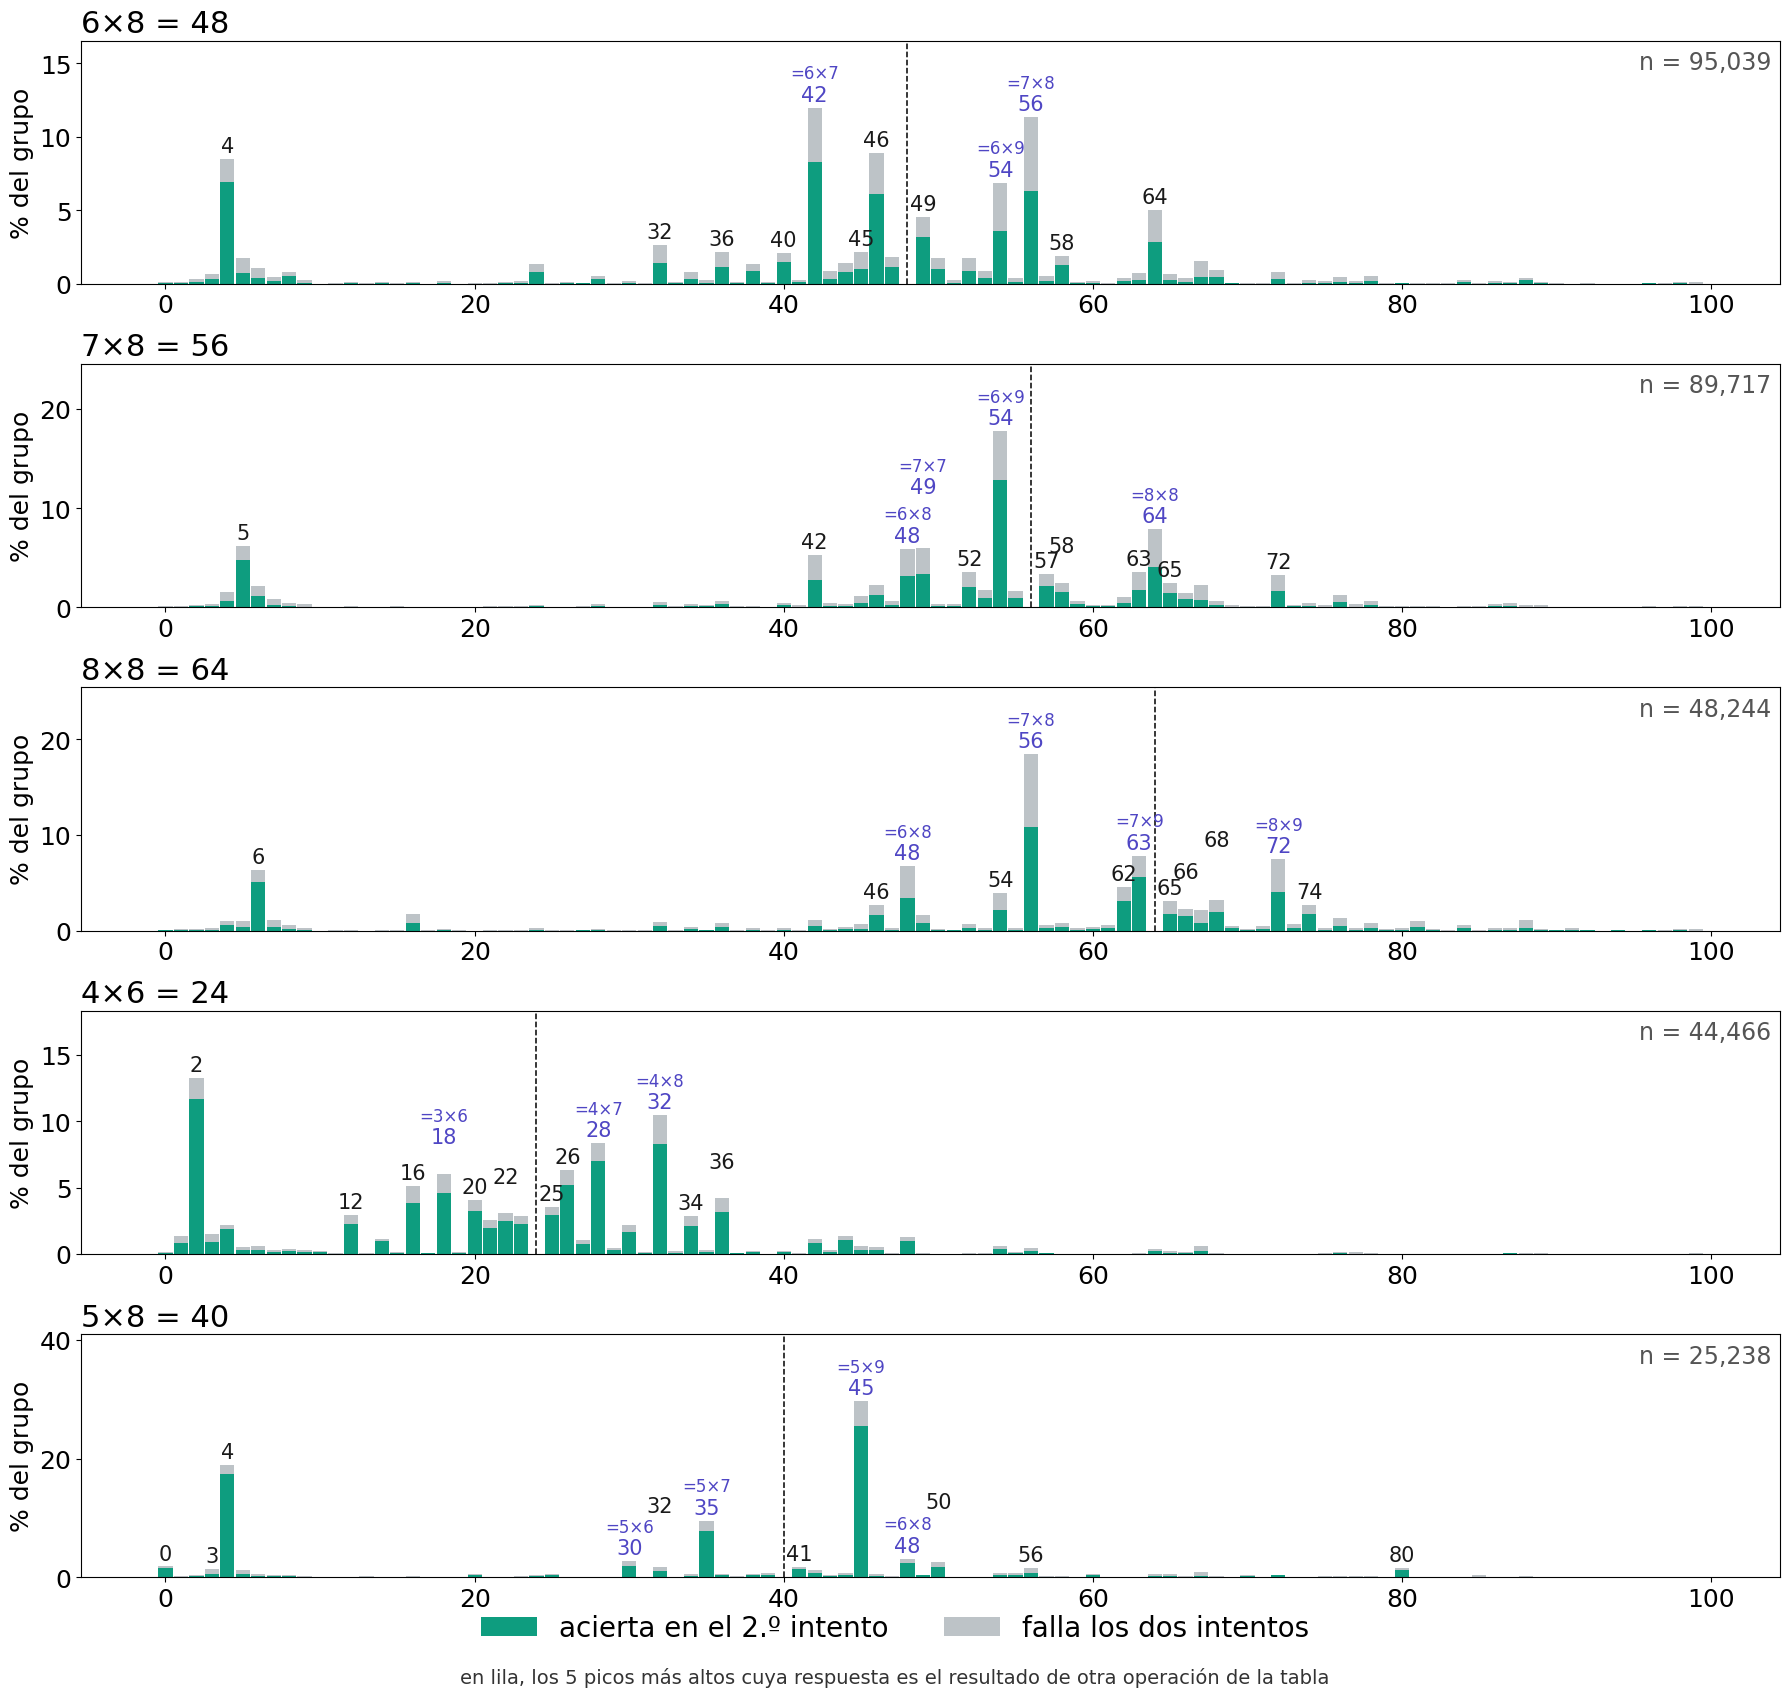

-> plots/fluency_hardest_errors_attempt1_ages09_11.png


In [5]:
# --- FIG A collapsed: every grade EXCEPT the 8-year-olds -------------------
# One figure per attempt with the grades merged, leaving out the 8-year-olds
# (3rd of Primaria). It replaces the per-grade figures this notebook used to
# have (one per grade and attempt), deleted on 2026-08-12.
#
# WHY THEY CAN BE MERGED, and why 8 stays out: not an aesthetic decision, a
# measurable one. The cosine similarity between the answer profiles of two
# grades (a 100-position vector, 1st attempt, per operation) is:
#   9-10, 9-11, 10-11 ... 0.984 to 0.999  -> practically the same histogram
#   8 against any other ... 0.858 to 0.949  -> always the lowest pair
# That is: from 4th to 6th they give the same wrong answers in the same
# proportions, and 3rd does not. Merging 4th-6th hides no difference; merging
# 3rd into them does. The calculation is repeated below on live data, it is not
# taken on trust.
#
# HOW THEY ARE MERGED: by summing n, i.e. "of ALL the wrong answers from 4th to
# 6th, what % is 54". No weighting by grade is needed: the three grades
# contribute 34%, 31.7% and 34.3% of the errors, and the gap between weighting
# by n and the plain mean of the three percentages is at most 0.75 pp, usually
# under 0.2 pp. With weights that equal the two definitions are the same figure;
# the sum is used because it is the one with a direct reading.
#
# The grades come from AGES, which cell 1 has already filtered by
# MIN_CELL_ERRORS (that is why 12 and 14 are not there: 9 and 1 numeric answers
# in total).
# --- colours ----------------------------------------------------------------
# These used to live in the FIG A cell, which is gone, so they live here:
# without these two lines the cell dies with a NameError.
#   bright green from the mint family of the poster + the original light grey.
# Note for a possible black-and-white print: the luminance contrast between the
# two is 1.9:1 (the blue that was here before had 3.1:1), so in greyscale the
# two parts of the bar would look much alike. In colour they are more than
# distinguishable, because what separates them is HUE -- saturated green against
# neutral grey. If the grey version is ever needed, darken the grey to #6e6e6e.
COLOR_RECOVERED = "#0e9d7f"   # got it right at the 2nd attempt
COLOR_FAILED = "#bdc3c7"      # failed both attempts

# --- marking the peaks that are the product of ANOTHER fact ----------------
# The MARK_TOP_N highest peaks of each operation get a second line saying which
# other multiplication gives that number: the 56 inside 6x8 carries "=7x8".
#
# WHAT CAME OUT OF LOOKING AT IT (1st attempt, 4th-6th): of the 30 highest peaks
# (6 per operation), 27 ARE the product of another fact. Only three are not: the
# 34 of 4x8, the 46 of 6x8 and the 62 of 8x8. So "it is another fact" separates
# almost nothing -- nearly every peak is one.
# Every label that carries an operation is marked in PURPLE, with no further
# distinction (Maria's decision, 2026-08-12: cleaner). The purple is a dark
# version of the #b9c1f5 of the poster -- the light one is unreadable as text.
# A version with three levels (shares a factor / both factors moved / not a fact
# at all) was tried and dropped as too busy. If you ever want it back: the
# condition is `f.lo in pair or f.hi in pair`, and the only two cases with both
# factors moved are 54 inside 7x8 and 63 inside 8x8.
#
# It canNOT be read off `error_type`: the taxonomy in the SQL has priorities and
# labels the 54 inside 7x8 as 'off_by_one' (|54-56| = 2) even though it is also
# 6x9, and the same for the 63 inside 8x8. It is computed here.
#
# ONE-DIGIT ANSWERS ARE NEVER MARKED: a 4, a 5 or a 6 is a truncated answer (the
# tens digit of the product, sent half typed). Putting "=1x4" on it would credit
# a calculation the pupil never did, so they keep the bare number.
TABLE_MAX = 12                # Fluency drills up to 12 (hence 4x12 shows up)
MARK_TOP_N = 5                # how many peaks per panel get the operation
COL_PLAIN = "#1a1a1a"         # plain label
COL_MARK = "#4f46c4"          # the answer is another operation result


def other_fact(value, lo, hi, table_max=TABLE_MAX):
    """(a, b) with a*b == value, or None if the value is no fact of the table.
    A value can have more than one decomposition (36 = 4x9 = 6x6, 48 = 6x8 =
    4x12); the same rule always picks one: first those that share a factor with
    the operation on the card and, among those, the closest to (lo, hi)."""
    pairs = [(a, value // a) for a in range(1, table_max + 1)
             if value % a == 0 and a <= value // a <= table_max]
    if not pairs:
        return None
    dist = lambda p: min(abs(p[0] - lo) + abs(p[1] - hi),
                         abs(p[0] - hi) + abs(p[1] - lo))
    shares = [p for p in pairs if lo in p or hi in p]
    return min(shares or pairs, key=dist)

EXCLUDE_AGE = 8
POOL_AGES = [a for a in AGES if a != EXCLUDE_AGE]
POOL_LABEL = "4.º-6.º (9-11 años)"

# --- font size --------------------------------------------------------------
# The figure text goes at FONT_BASE (titles, axes, ticks, legend). The peak
# labels do NOT: they are annotations pinned to a position on the x axis, and
# with 100 positions across 18 inches there are ~18 px per unit -- at 22 pt a
# two-digit number takes more than 30 and neighbouring peaks (48/49, 65/66)
# would overlap. They stay at ANNOT_FONT and what grows is the canvas.
FONT_BASE = 22
ANNOT_FONT = 15
FIG_W, PANEL_H = 18, 3.4
# Only the 1st attempt is drawn (FIG A); attempt 2 lives on in the tables above.
ATTEMPT_NO = 1

# --- the check: how similar are the grades to each other? ------------------
d1 = plot[plot["attempt_no"] == 1]
print("Similitud cosinus entre perfils de resposta (1r intent, 0-99):")
worst_pool, best_excluded = 1.0, 0.0
for f in facts.itertuples():
    sub = d1[(d1["lo"] == f.lo) & (d1["hi"] == f.hi)]
    vecs = {}
    for a in AGES:
        v = (sub[sub["classroom_course_age"] == a].groupby("user_answer")["n"].sum()
             .reindex(range(100), fill_value=0).to_numpy(float))
        vecs[a] = v / v.sum()
    pairs = {}
    for i, a in enumerate(AGES):
        for b in AGES[i + 1:]:
            va, vb = vecs[a], vecs[b]
            pairs[(a, b)] = float(va @ vb / np.sqrt((va @ va) * (vb @ vb)))
    in_pool = [c for (a, b), c in pairs.items() if a != EXCLUDE_AGE and b != EXCLUDE_AGE]
    with_excl = [c for (a, b), c in pairs.items() if EXCLUDE_AGE in (a, b)]
    worst_pool = min(worst_pool, min(in_pool))
    best_excluded = max(best_excluded, max(with_excl))
    print(f"  {f.lo}×{f.hi}: dins de {POOL_AGES} {min(in_pool):.3f}-{max(in_pool):.3f}"
          f"   |   contra {EXCLUDE_AGE} anys {min(with_excl):.3f}-{max(with_excl):.3f}")
print(f"\nPitjor parell DINS del grup fos: {worst_pool:.3f}"
      f" | millor parell CONTRA {EXCLUDE_AGE} anys: {best_excluded:.3f}")
assert worst_pool > best_excluded, \
    f"El curs de {EXCLUDE_AGE} anys no es l'outlier: no hi ha motiu per deixar-lo fora"

w = (plot[(plot["attempt_no"] == 1) & (plot["classroom_course_age"].isin(POOL_AGES))]
     .groupby("classroom_course_age")["n"].sum())
print(f"\nPes de cada curs dins del grup fos: "
      + ", ".join(f"{a}: {100 * n / w.sum():.1f}%" for a, n in w.items()))

def plot_pooled():
    """Same panels as the per-grade figures that used to be here, but summing
    the grades of POOL_AGES. Figure text in Spanish; comments in English and
    printed output in Catalan, like the rest of the notebook."""
    d_pool = plot[(plot["classroom_course_age"].isin(POOL_AGES))
                  & (plot["attempt_no"] == ATTEMPT_NO)]
    fig, axes = plt.subplots(len(facts), 1, figsize=(FIG_W, PANEL_H * len(facts)),
                             squeeze=False)
    for i, f in enumerate(facts.itertuples()):
        ax = axes[i][0]
        d = d_pool[(d_pool["lo"] == f.lo) & (d_pool["hi"] == f.hi)]
        tot = d["n"].sum()
        rec = (d[d["recovered_at_second"] == 1].groupby("user_answer")["n"].sum()
               .reindex(range(0, 100), fill_value=0))
        fai = (d[d["recovered_at_second"] == 0].groupby("user_answer")["n"].sum()
               .reindex(range(0, 100), fill_value=0))
        ax.bar(rec.index, 100 * rec / tot, width=0.92, color=COLOR_RECOVERED)
        ax.bar(fai.index, 100 * fai / tot, width=0.92, color=COLOR_FAILED,
               bottom=100 * rec / tot)
        height = 100 * (rec + fai) / tot

        ax.axvline(f.product, color="black", ls="--", lw=1.1)
        # Labels sit right by their own bar. Only the one that would really
        # collide with its neighbour goes up a level, and colliding takes TWO
        # things at once: the two peaks 2 units apart or less (at this size a
        # two-digit number is wider than the distance between neighbouring
        # answers) AND the two bars at a similar height. If the neighbour is
        # much taller or much shorter the labels already end up at different
        # heights and nothing needs moving: raising it anyway left it floating
        # far from its own bar.
        # The "similar height" threshold is one line of text converted into data
        # units -- ANNOT_FONT points over the panel height in points -- so it
        # still holds if you change ANNOT_FONT or PANEL_H.
        peaks = height[height >= ANNOT_FLOOR_PCT].nlargest(ANNOT_TOP_N).sort_index()
        marked = set(height.nlargest(MARK_TOP_N).index)
        same_height = (ANNOT_FONT + 4) / (PANEL_H * 72) * max(height.max(), 1e-9) * 1.3
        # `occupied` = how many lines of text the previous label takes, counting
        # from its own bar. That way, if the neighbour is a marked peak with two
        # lines (the number and "=7x8"), the next one jumps TWO lines instead of
        # one: that was what dropped the "=6x8" of the 48 on top of the 49.
        last_x, last_y, occupied = -99, 0.0, 0
        for x, y in peaks.items():
            collides = (x - last_x <= 2) and (abs(y - last_y) < same_height)
            level = occupied if collides else 0
            dy = 2 + level * (ANNOT_FONT + 2)

            truncada = x < 10 <= f.product        # half-typed answer, not a calculation
            pair = (other_fact(int(x), f.lo, f.hi)
                    if (x in marked and not truncada) else None)
            color = COL_MARK if pair is not None else COL_PLAIN

            ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, dy),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=ANNOT_FONT, color=color)
            if pair is not None:
                ax.annotate(f"={pair[0]}×{pair[1]}", xy=(x, y),
                            xytext=(0, dy + ANNOT_FONT + 1),
                            textcoords="offset points", ha="center", va="bottom",
                            fontsize=ANNOT_FONT - 3, color=color)
            last_x, last_y = x, y
            occupied = level + (2 if pair is not None else 1)


        # Room above the panel: without this the label of the highest peak ends
        # up glued to the top edge. It is an AUTOSCALE margin (a fraction of
        # the range, set just below), not a fixed ylim, so it keeps working if
        # the data changes; and then 0 is pinned back at the bottom, because a
        # bar has to start from zero and the margin would push it down too.
        ax.set_ymargin(0.38)   # worst case: a shifted label on top of a two-line one
        ax.autoscale_view()
        ax.set_ylim(bottom=0)

        ax.set_title(f"{f.lo}×{f.hi} = {f.product}", fontsize=FONT_BASE, loc="left")
        ax.set_ylabel("% del grupo", fontsize=FONT_BASE - 4)
        ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)
        # The "the correct one is not drawn" note used to sit on all five panels
        # and collided with the peak of 4x8. It is the same message five times,
        # so it was moved to the figure subtitle -- which is no longer drawn,
        # so right now the note does not appear in the figure at all.
        ax.annotate(f"n = {int(tot):,}", xy=(0.995, 0.96), xycoords="axes fraction",
                    ha="right", va="top", fontsize=FONT_BASE - 5, color="#555555")

    fig.legend(handles=[Patch(facecolor=COLOR_RECOVERED, label="acierta en el 2.º intento"),
                        Patch(facecolor=COLOR_FAILED, label="falla los dos intentos")],
               loc="lower center", ncol=2, frameon=False, fontsize=FONT_BASE - 2,
               bbox_to_anchor=(0.5, -0.004))
    fig.text(0.5, -0.004,
             f"en lila, los {MARK_TOP_N} picos más altos cuya respuesta es el"
             " resultado de otra operación de la tabla",
             ha="center", va="top", fontsize=ANNOT_FONT - 1, color="#333333")
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))
    out = (HERE / "plots"
           / f"fluency_hardest_errors_attempt{ATTEMPT_NO}_ages{POOL_AGES[0]:02d}_{POOL_AGES[-1]:02d}")
    fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
    plt.show()
    print(f"-> plots/{out.name}.png")

plot_pooled()


Finestra x = [30, 70] | intent 1 | cursos [9, 10, 11]
  6×8 = 48 (producte dins de la finestra)
    denominador = 463,118 cartes vistes = 292,284 correctes al 1r intent (63.1%) + 95,039 errors numerics dibuixats (20.5%) + 75,795 NO dibuixats (16.4%: sense resposta, massa xifres, guessing <1,2 s)
    fora del retall: 4.5% | pics perduts > 1%: 4 (1.7%)


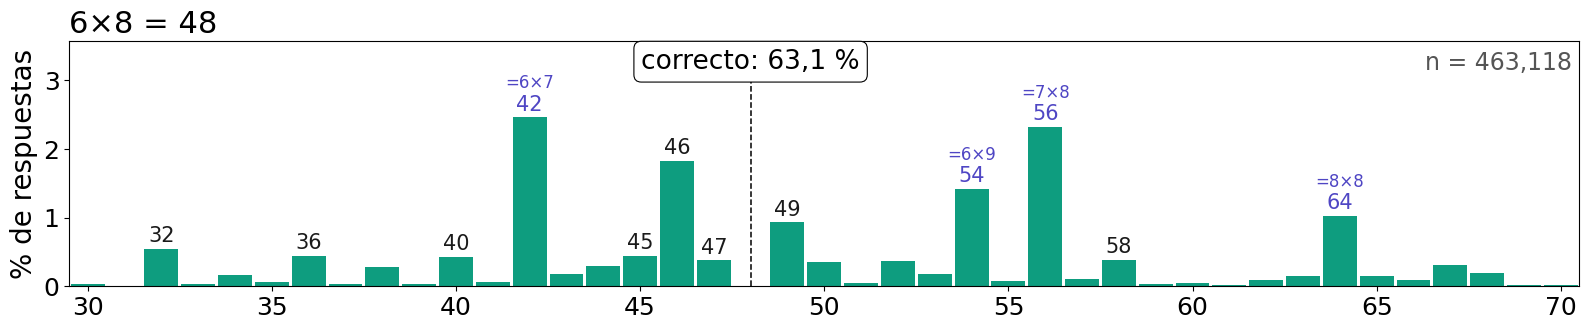

-> plots/fluency_hardest_errors_attempt1_ages09_11_top1_x30_70_solid.png


In [13]:
# --- ZOOM: 6x8 only, x axis cropped to 30-70 -------------------------------
# POSTER VERSION (2026-09-01, Maria). Two changes from the version that had the
# green/grey recovery split:
#
#   1. ONE SOLID COLOUR, NO LEGEND. There is no second-attempt information in
#      the figure any more. If you want the green/grey back, cell 4 (the
#      5-panel figure) and cell 9 (6x8 grade by grade) still have it.
#   2. THE Y AXIS IS A % OF ALL THE CARDS SEEN (n_cards = correct at first +
#      wrong at first), not a % of the wrong answers. The dashed line carries
#      the % that got it right.
#
# WHY n_cards AND NOT "correct + the bars I draw" -- this was got wrong once, on
# 2026-09-01, so it is written down. Of the 170,834 cards of 6x8 missed at the
# 1st attempt by grades 4th-6th, only 95,039 can be drawn. The other 75,795 are:
#   . no_answer        69,772 (41% of the wrong ones). user_answer is NULL --
#                      no value recorded at all, so there is no position for it
#                      on a 0-99 axis. SEE THE NOTE ON THE CLOCK BELOW.
#   . too_many_digits   4,953. Numbers, but off the axis (488, 448, 456): the
#                      right answer with one key too many. Typing, not
#                      arithmetic, and four values in the hundreds would stretch
#                      the axis flat.
#   . equals_product        0 here. Graded wrong with the correct answer; it
#                      would put a bar exactly on the dashed line.
#   . <1.2 s               1,070 fast guesses, dropped by the .sql (2026-08-14).
# Taking those out of the DENOMINATOR (instead of only out of the drawing)
# pushes the correct rate from 63.1% to 75.5% and contradicts the error rate of
# the 5-panel figure (36.9% pooled; 37.2 / 38.6 / 35.1 by grade). So they stay
# in the denominator: the bars add up to 20.5%, the label says 63.1%, and the
# missing 16.4% IS the group that cannot be drawn. The panel prints it.
#
# THE CLOCK (found 2026-09-01, NOT yet verified against raw durations): the
# median duration of the no_answer group sits on exact round values and moves
# with the grade -- 6x8: 30.00 s at 8 years, 20.03 at 9, 10.03 at 10 and 11;
# 5x8: 25.01 / 15.03 / 10.03 / 10.03. That is a timeout, not a pupil walking
# away, and it means this app DOES have a time limit -- which contradicts the
# "no timer" this notebook's header and the .sql both state. Do not write "they
# leave the card half done" on the poster until this is checked.
#
# CAREFUL, the x crop is a deliberate EXCEPTION to this project's rule of never
# putting limits on the x axis (2026-07-20). What falls outside does NOT leave
# the calculation -- the denominator is the same -- so heights stay comparable
# with the other figures. For 6x8 that is 4.5% of the cards, mostly the 4
# (1.75%, the tens digit of 48 sent half typed).
#
# BACKGROUND (2026-08-14): the panel rectangle goes WHITE and everything around
# it transparent, so it can be mounted on the lilac of the poster.
N_FACTS = 1               # only the 1st row of `facts` -- 6x8, the hardest
X_MIN, X_MAX = 30, 70     # x axis window
FIG_W_ZOOM = 16           # stretched sideways: a single panel over 40 positions
COLOR_BAR = "#0e9d7f"     # solid mint green, the poster family. Defined here and
                          # not taken from cell 4 so this cell stands alone.
SHOW_MISSING_NOTE = False # True adds a second line under the label saying how
                          # much is not drawn

facts_zoom = facts.head(N_FACTS)


def denominator_pool(f):
    """(correct at first, numeric wrong answers drawn, ALL cards seen).

    n_cards and n_correct_first are per-(fact, age) columns that the query
    repeats on every row of the cell, so they MUST be deduplicated before
    summing or the total is inflated by the number of distinct answers.
    """
    m = ((err["lo"] == f.lo) & (err["hi"] == f.hi)
         & (err["classroom_course_age"].isin(POOL_AGES)))
    cells = err[m].drop_duplicates(["lo", "hi", "classroom_course_age"])
    n_cards = int(cells["n_cards"].sum())
    n_ok = int(cells["n_correct_first"].sum())
    n_err = int(plot[(plot["lo"] == f.lo) & (plot["hi"] == f.hi)
                     & (plot["classroom_course_age"].isin(POOL_AGES))
                     & (plot["attempt_no"] == ATTEMPT_NO)]["n"].sum())
    return n_ok, n_err, n_cards


def plot_pooled_zoom():
    d_pool = plot[(plot["classroom_course_age"].isin(POOL_AGES))
                  & (plot["attempt_no"] == ATTEMPT_NO)]

    print(f"Finestra x = [{X_MIN}, {X_MAX}] | intent {ATTEMPT_NO} | cursos {POOL_AGES}")
    for f in facts_zoom.itertuples():
        n_ok, n_err, denom = denominator_pool(f)
        n_hidden = denom - n_ok - n_err
        d = d_pool[(d_pool["lo"] == f.lo) & (d_pool["hi"] == f.hi)]
        s = d.groupby("user_answer")["n"].sum().reindex(range(100), fill_value=0)
        pct = 100 * s / denom
        fora = pct[(pct.index < X_MIN) | (pct.index > X_MAX)]
        dins_producte = X_MIN <= f.product <= X_MAX
        print(f"  {f.lo}×{f.hi} = {f.product} (producte "
              f"{'dins' if dins_producte else 'FORA'} de la finestra)")
        print(f"    denominador = {denom:,} cartes vistes = "
              f"{n_ok:,} correctes al 1r intent ({100 * n_ok / denom:.1f}%)"
              f" + {n_err:,} errors numerics dibuixats ({100 * n_err / denom:.1f}%)"
              f" + {n_hidden:,} NO dibuixats ({100 * n_hidden / denom:.1f}%:"
              f" sense resposta, massa xifres, guessing <1,2 s)")
        print(f"    fora del retall: {fora.sum():.1f}% | pics perduts > 1%: "
              + ", ".join(f"{int(v)} ({p:.1f}%)"
                          for v, p in fora[fora > 1].sort_values(ascending=False).items()))

    fig, axes = plt.subplots(len(facts_zoom), 1,
                             figsize=(FIG_W_ZOOM, PANEL_H),
                             squeeze=False)
    for i, f in enumerate(facts_zoom.itertuples()):
        ax = axes[i][0]
        n_ok, n_err, denom = denominator_pool(f)
        d = d_pool[(d_pool["lo"] == f.lo) & (d_pool["hi"] == f.hi)]

        # ONE bar per answer, one colour: no recovered/failed stacking any more.
        height = (d.groupby("user_answer")["n"].sum()
                   .reindex(range(0, 100), fill_value=0)) * 100 / denom
        ax.bar(height.index, height.values, width=0.92, color=COLOR_BAR)

        ax.axvline(f.product, color="black", ls="--", lw=1.1)

        # Peaks are picked ONLY among the visible bars: otherwise peaks outside
        # the crop (the 4) would eat ANNOT_TOP_N labels and tall bars inside the
        # window would be left without a number.
        # ANNOT_FLOOR_PCT is scaled: it was set (1.0) for a % of the WRONG
        # answers, and this denominator is ~4.9x bigger, so the raw 1.0 would
        # leave every bar unlabelled.
        floor = ANNOT_FLOOR_PCT * (n_err / denom)
        visible = height[(height.index >= X_MIN) & (height.index <= X_MAX)]
        peaks = visible[visible >= floor].nlargest(ANNOT_TOP_N).sort_index()
        marked = set(visible.nlargest(MARK_TOP_N).index)
        same_height = (ANNOT_FONT + 4) / (PANEL_H * 72) * max(visible.max(), 1e-9) * 1.3
        last_x, last_y, occupied = -99, 0.0, 0
        for x, y in peaks.items():
            collides = (x - last_x <= 2) and (abs(y - last_y) < same_height)
            level = occupied if collides else 0
            dy = 2 + level * (ANNOT_FONT + 2)

            truncada = x < 10 <= f.product        # half-typed answer, not a calculation
            pair = (other_fact(int(x), f.lo, f.hi)
                    if (x in marked and not truncada) else None)
            color = COL_MARK if pair is not None else COL_PLAIN

            ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, dy),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=ANNOT_FONT, color=color)
            if pair is not None:
                ax.annotate(f"={pair[0]}×{pair[1]}", xy=(x, y),
                            xytext=(0, dy + ANNOT_FONT + 1),
                            textcoords="offset points", ha="center", va="bottom",
                            fontsize=ANNOT_FONT - 3, color=color)
            last_x, last_y = x, y
            occupied = level + (2 if pair is not None else 1)

        # THE Y SCALE COMES FROM THE VISIBLE BARS, not from all of them: with
        # normal autoscaling the 4 (outside the crop) would still drive the
        # panel height. 1.45 instead of 1.38 to leave room for the label that
        # now sits on top of the dashed line.
        ax.set_xlim(X_MIN - 0.5, X_MAX + 0.5)
        ax.set_ylim(0, visible.max() * 1.45)

        # THE LABEL ON THE DASHED LINE: % of the cards answered right at the
        # first attempt. Blended transform -- x in data units so it follows the
        # line, y in axes units so it always sits just under the top edge.
        # It is a % of ANSWERS, not of pupils: Fluency is Leitner, one pupil
        # sees the same card many times and every sighting counts once.
        pct_ok = 100 * n_ok / denom
        label = f"correcto: {pct_ok:.1f} %".replace(".", ",")
        if SHOW_MISSING_NOTE:
            pct_hidden = 100 * (denom - n_ok - n_err) / denom
            label += f"\n({pct_hidden:.1f} % sin respuesta registrada)".replace(".", ",")
        ax.text(f.product, 0.97, label,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=FONT_BASE - 3, linespacing=1.35,
                bbox=dict(boxstyle="round,pad=0.28", facecolor="white",
                          edgecolor="black", linewidth=0.8))

        # BACKGROUND: the panel rectangle goes WHITE and everything around it
        # transparent. That is the axes patch against the figure patch, two
        # different things; this is why savefig(transparent=True) canNOT be
        # used -- it would empty BOTH and leave the rectangle transparent too.
        ax.set_facecolor("white")

        ax.set_title(f"{f.lo}×{f.hi} = {f.product}", fontsize=FONT_BASE, loc="left")
        ax.set_ylabel("% de respuestas", fontsize=FONT_BASE - 2)
        ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)
        # The n is the DENOMINATOR (all cards seen), so it matches the heights.
        # It is not the number of wrong answers any more.
        ax.annotate(f"n = {int(denom):,}", xy=(0.995, 0.96), xycoords="axes fraction",
                    ha="right", va="top", fontsize=FONT_BASE - 5, color="#555555")

    # No legend any more, so no reserved space at the bottom either.
    fig.tight_layout()

    # Only the FIGURE background is transparent (what surrounds the panel, where
    # title, ticks and label fall); the inside of the panel is already white.
    fig.patch.set_facecolor("none")

    out = (HERE / "plots" / f"fluency_hardest_errors_attempt{ATTEMPT_NO}"
           f"_ages{POOL_AGES[0]:02d}_{POOL_AGES[-1]:02d}_top{N_FACTS}"
           f"_x{X_MIN}_{X_MAX}_solid")
    fig.savefig(out.with_suffix(".png"), dpi=400, bbox_inches="tight",
                facecolor="none")
    plt.show()
    print(f"-> plots/{out.name}.png")


plot_pooled_zoom()

A998 | tipus d'error a les operacions amb 0
Font: bi_gold_prod.dm_research.fluency_test_statements JOIN fluency_test_metrics
Cursos: els mateixos que la figura de dalt, 4.º-6.º (9-11 años)
Files: 273 (fet x curs x resposta) | cache -> descriptive\cache/

Ranquing de tots els fets amb 0 (orientacions fusionades):
    n_attempts  n_wrong  err_pct
hi                              
1        37912     9609    25.35
9        38050     9105    23.93
7        37789     9003    23.82
2        37518     8882    23.67
6        37945     8780    23.14
8        37826     8691    22.98
3        37845     8573    22.65
4        37919     8564    22.58
5        37761     8414    22.28
0        18912     2748    14.53

Es dibuixen els 5 amb mes error: ['0×1', '0×9', '0×7', '0×2', '0×6']
Respostes per damunt de 9: 3 de 82,272 (0.004%) -- l'eix x va d'1 a 9


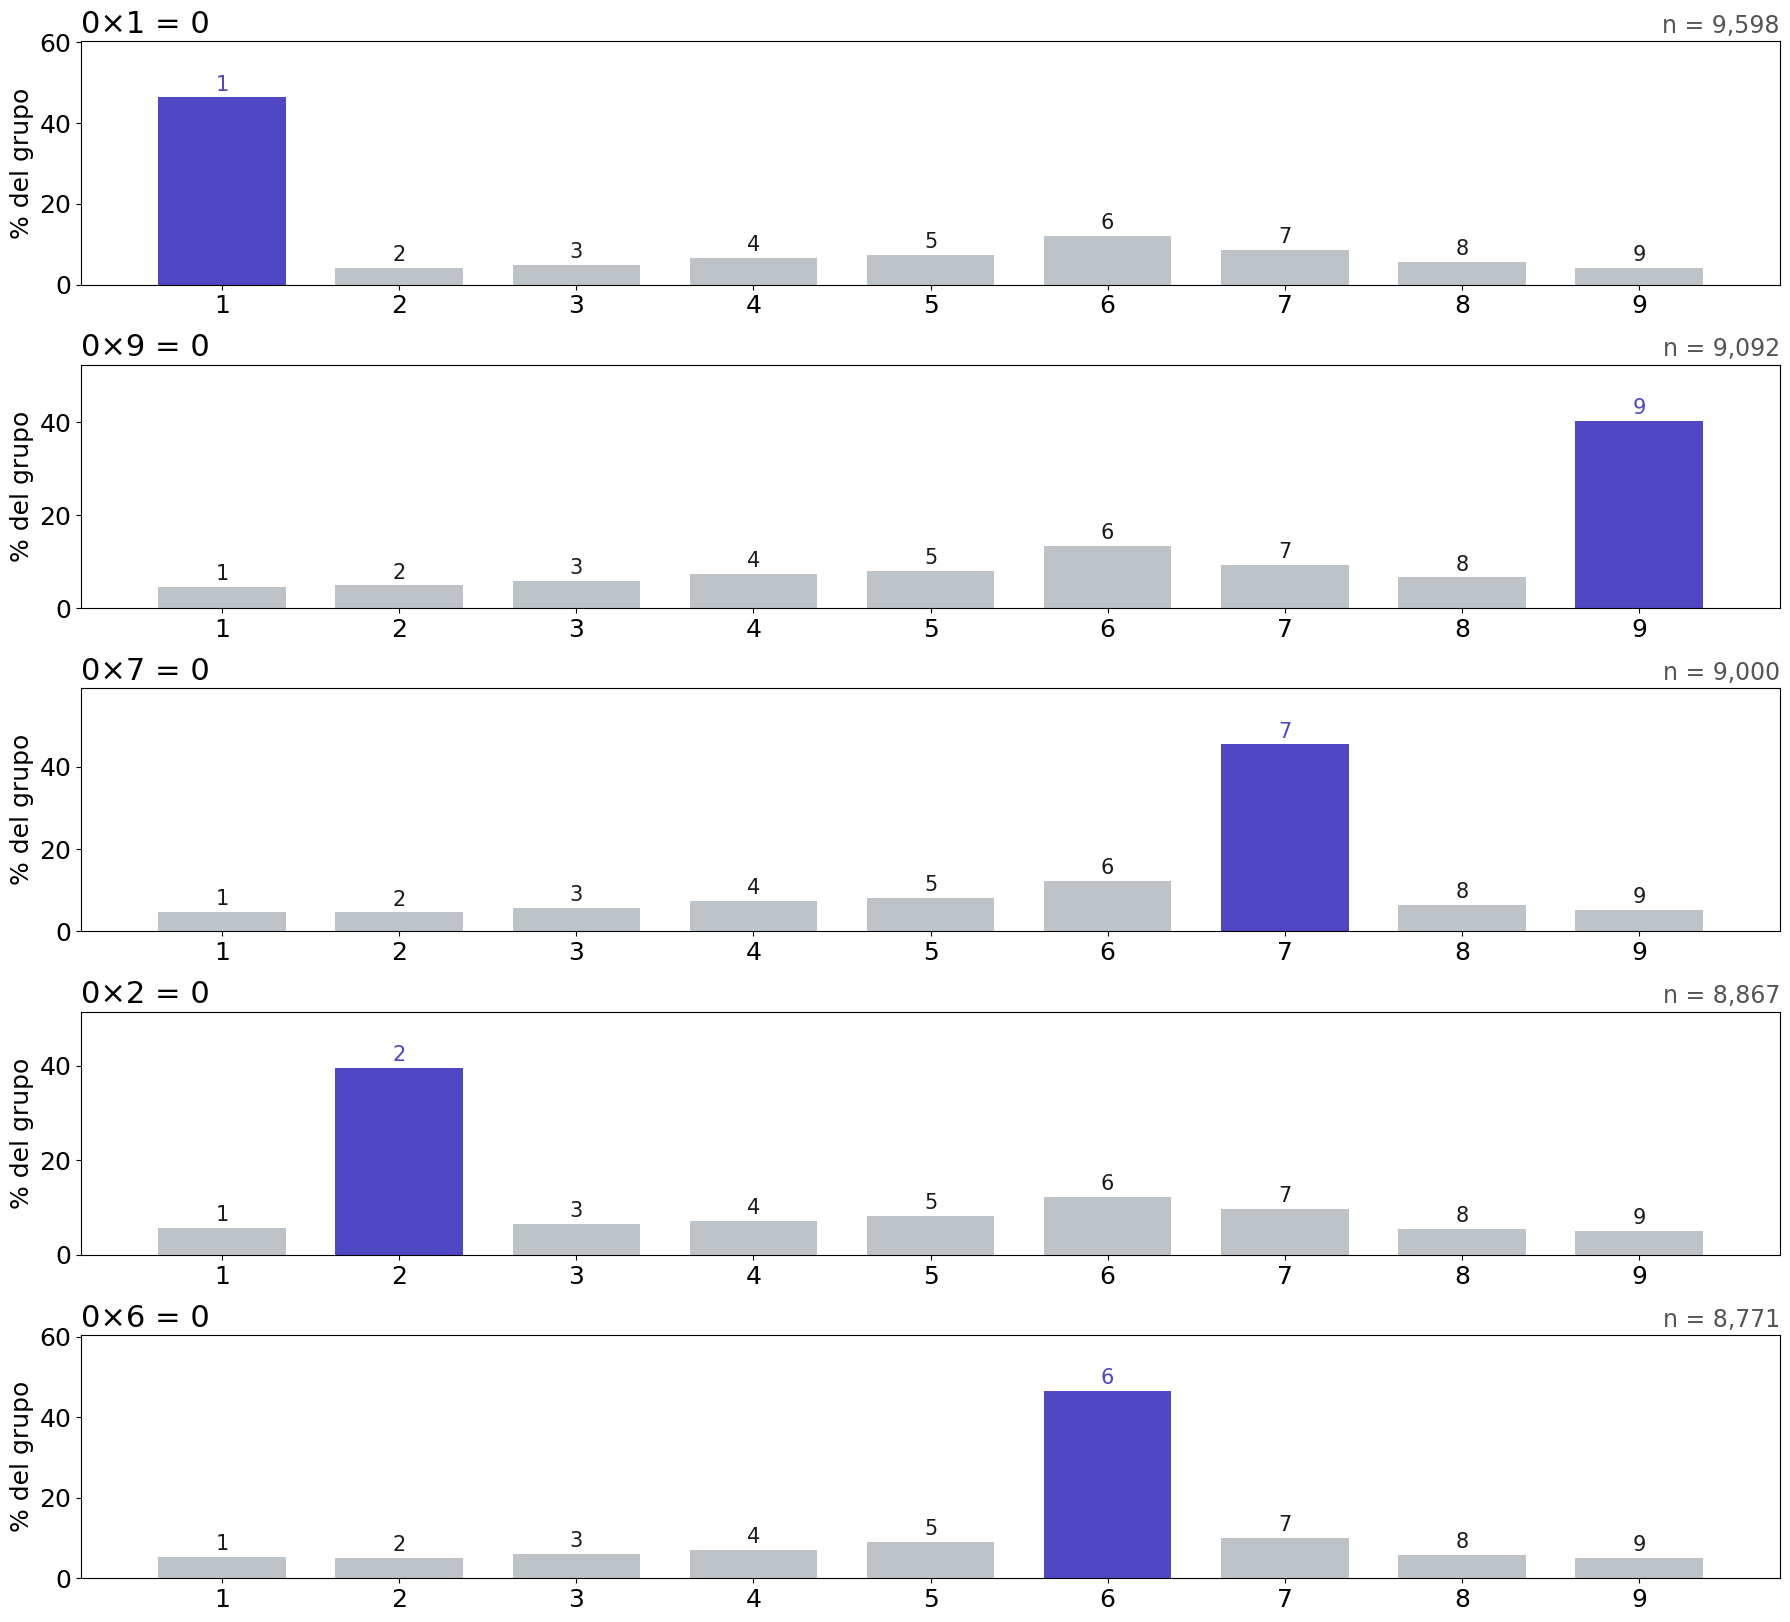

-> plots/a998_zero_errors_ages09_11.png / .pdf

Les dues poblacions (durada mediana de la resposta):
fet  pct_altre_factor  dur_altre_factor  dur_resta  2a_xifra
0×1             46.31              2.25       0.82         6
0×9             40.25              2.57       0.82         6
0×7             45.43              2.40       0.83         6
0×2             39.65              2.40       0.83         6
0×6             46.53              2.40       0.82         7
0×8             40.01              2.57       0.82         6
0×3             39.87              2.50       0.83         6
0×4             41.44              2.52       0.82         6
0×5             40.24              2.50       0.84         6
0×0              0.00               NaN       0.81         6


In [7]:
# --- A998: what do they answer when the operation carries a ZERO? ----------
# Same idea as the figure above, but with the 5 operations with 0 that have the
# most error. It has to come from A998 and not from Fluency: the Fluency zone
# has NO card with 0 (checked on 2026-08-12 against f_elementary_fluency_
# attempts: filtering any factor to 0 returns zero rows, and the factor
# inventory runs from 1 to 12). That is why this cell carries its own query.
#
# IT CANNOT BE COMPARED IN LEVEL with the Fluency figure above: two different
# apps (timed test against spaced practice with two attempts) and here there is
# no second attempt, so there is no recovered/failed split and the bars are of
# a single colour.
#
# THE X AXIS RUNS FROM 1 TO 9, and that is not a crop: the product of any fact
# with 0 is 0, so the first key that is not a 0 already makes the result
# impossible and A998 submits the answer on its own. What stays recorded is that
# first digit. Measured on 4th-6th: of 79,522 wrong answers, 3 are above 9 and
# 96 are empty. So this is a distribution of FIRST DIGITS. A pupil who meant to
# write 10 is recorded as 1. It is the same typing mechanism that makes the
# two-digit answers of A998 unreliable, but here it costs nothing: a one-digit
# answer has no second digit to lose.
#
# THE RANKING AMONG THE FACTS WITH 0 IS NEARLY FLAT (23-25%), with two
# exceptions: x1 stands out at the top and 0x0 at the bottom (14.5%). Taking
# "the 5 with the most error" is therefore a fairly arbitrary cut, and the cell
# prints the whole ranking so that it shows.
SQL_PATH_ZERO = HERE / "queries" / "a998_zero_facts_error_answers.sql"

sql_zero = SQL_PATH_ZERO.read_text(encoding="utf-8")
years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_zero, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", sql_zero)
assert n_y == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_y}"
sql_zero, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                        f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql_zero)
assert n_a == 1, f"Esperava 1 marcador -- {{AGES}}, n'he trobat {n_a}"

zero = cached_query(SQL_PATH_ZERO, CACHE_DIR, sql_text=sql_zero)
zero = zero[zero["classroom_course_age"].isin(POOL_AGES)]
print("A998 | tipus d'error a les operacions amb 0")
print("Font: bi_gold_prod.dm_research.fluency_test_statements JOIN fluency_test_metrics")
print(f"Cursos: els mateixos que la figura de dalt, {POOL_LABEL}")
print(f"Files: {len(zero):,} (fet x curs x resposta) | cache -> {CACHE_DIR.relative_to(ROOT)}/")

# Error rate per fact, merging orientations (7x0 and 0x7 are the same row).
# n_attempts and n_wrong come repeated on every row of the same (fact, grade),
# so the cells are deduplicated first and summed afterwards.
cells_zero = zero.drop_duplicates(["hi", "classroom_course_age"])
rank_zero = (cells_zero.groupby("hi")[["n_attempts", "n_wrong"]].sum()
             .assign(err_pct=lambda d: 100 * d["n_wrong"] / d["n_attempts"])
             .sort_values("err_pct", ascending=False))
print("\nRanquing de tots els fets amb 0 (orientacions fusionades):")
print(rank_zero.round(2).to_string())

ZERO_TOP = list(rank_zero.head(5).index)
print(f"\nEs dibuixen els 5 amb mes error: {['0×' + str(h) for h in ZERO_TOP]}")

# Ceiling check for the axis: if two-digit answers ever showed up in volume,
# this would warn instead of cropping them silently.
fora = zero[zero["user_answer"] > 9]["n"].sum()
print(f"Respostes per damunt de 9: {int(fora):,} de {int(zero['n'].sum()):,}"
      f" ({100 * fora / zero['n'].sum():.3f}%) -- l'eix x va d'1 a 9")

ANSWERS = list(range(1, 10))
fig, axes = plt.subplots(len(ZERO_TOP), 1, figsize=(FIG_W, PANEL_H * len(ZERO_TOP)),
                         squeeze=False)
for i, hi in enumerate(ZERO_TOP):
    ax = axes[i][0]
    d = zero[zero["hi"] == hi]
    tot = d["n"].sum()
    s = d.groupby("user_answer")["n"].sum().reindex(ANSWERS, fill_value=0)
    height = 100 * s / tot

    # The only marked bar is the one equal to the OTHER FACTOR: that is 0 read
    # as the neutral element. Marking "it is the result of another fact" makes
    # no sense here, because with one-digit answers every value is one.
    colors = [COL_MARK if a == hi else COLOR_FAILED for a in ANSWERS]
    ax.bar(ANSWERS, height, width=0.72, color=colors)

    for a, y in height.items():
        marca = a == hi
        ax.annotate(f"{a}", xy=(a, y), xytext=(0, 2), textcoords="offset points",
                    ha="center", va="bottom", fontsize=ANNOT_FONT,
                    color=COL_MARK if marca else COL_PLAIN)

    ax.set_ymargin(0.30)
    ax.autoscale_view()
    ax.set_ylim(bottom=0)
    ax.set_xticks(ANSWERS)
    ax.set_title(f"0×{hi} = 0", fontsize=FONT_BASE, loc="left")
    # The n goes in the title and not inside the panel: here the marked bar can
    # be the 9, i.e. the far right, where it collided with the "n = ...".
    ax.set_title(f"n = {int(tot):,}", fontsize=FONT_BASE - 5, loc="right",
                 color="#555555")
    ax.set_ylabel("% del grupo", fontsize=FONT_BASE - 4)
    ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)

fig.tight_layout(rect=(0, 0.02, 1, 0.98))
out = HERE / "plots" / f"a998_zero_errors_ages{POOL_AGES[0]:02d}_{POOL_AGES[-1]:02d}"
fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(f"-> plots/{out.name}.png / .pdf")

# --- the two populations: the considered answer and the keystroke ----------
# The % does not say it all; the duration does. The answer equal to the other
# factor comes with a median of ~2.3-2.6 s, while ALL the other digits sit at
# ~0.8 s. They are not the same phenomenon mixed together: one is a considered
# answer (0 treated as the neutral element) and the other is fast typing at the
# end of the pack, the same noise as Decision #12. That is why the second most
# frequent digit is always a 6 or a 7, the same for every fact.
print("\nLes dues poblacions (durada mediana de la resposta):")
res = []
for hi in rank_zero.index:
    d = zero[(zero["hi"] == hi) & (zero["user_answer"].between(1, 9))]
    tot = d["n"].sum()
    altre = d[d["user_answer"] == hi]
    resta = d[d["user_answer"] != hi]
    segona = (resta.groupby("user_answer")["n"].sum().idxmax()
              if len(resta) else None)
    res.append({
        "fet": f"0×{hi}",
        "pct_altre_factor": 100 * altre["n"].sum() / tot if tot else np.nan,
        "dur_altre_factor": altre["median_duration"].median(),
        "dur_resta": resta["median_duration"].median(),
        "2a_xifra": segona,
    })
print(pd.DataFrame(res).round(2).to_string(index=False))


FLUIDESA | tipus d'error a la TAULA DEL 9
YEARS = ['ES_2025'] | edats 8-15 | guessing rapid <1.2s exclos de les respostes errronies (mateix .sql que la figura de dalt)
Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts
      JOIN dwh_global_dimensions_historic.d_students per student_uuid
Files: 39,921 (fet x curs x intent x resposta) | cache -> descriptive\cache/

La taula del 9 dins de la dificultat de FLUIDESA (ranquing sobre TOTS
els fets de l'app, no nomes aquests 12):
  operacio  fluency_rank  fluency_error_pct  n_fact
9×12 = 108             4             39.858  492368
  6×9 = 54            16             27.723  434966
  7×9 = 63            18             27.091  418752
  4×9 = 36            19             26.892  498797
  8×9 = 72            21             26.217  457527
  3×9 = 27            28             19.324  415729
  5×9 = 45            32             16.580  408443
  9×9 = 81            37             12.074  170627
 9×11 = 99            39           

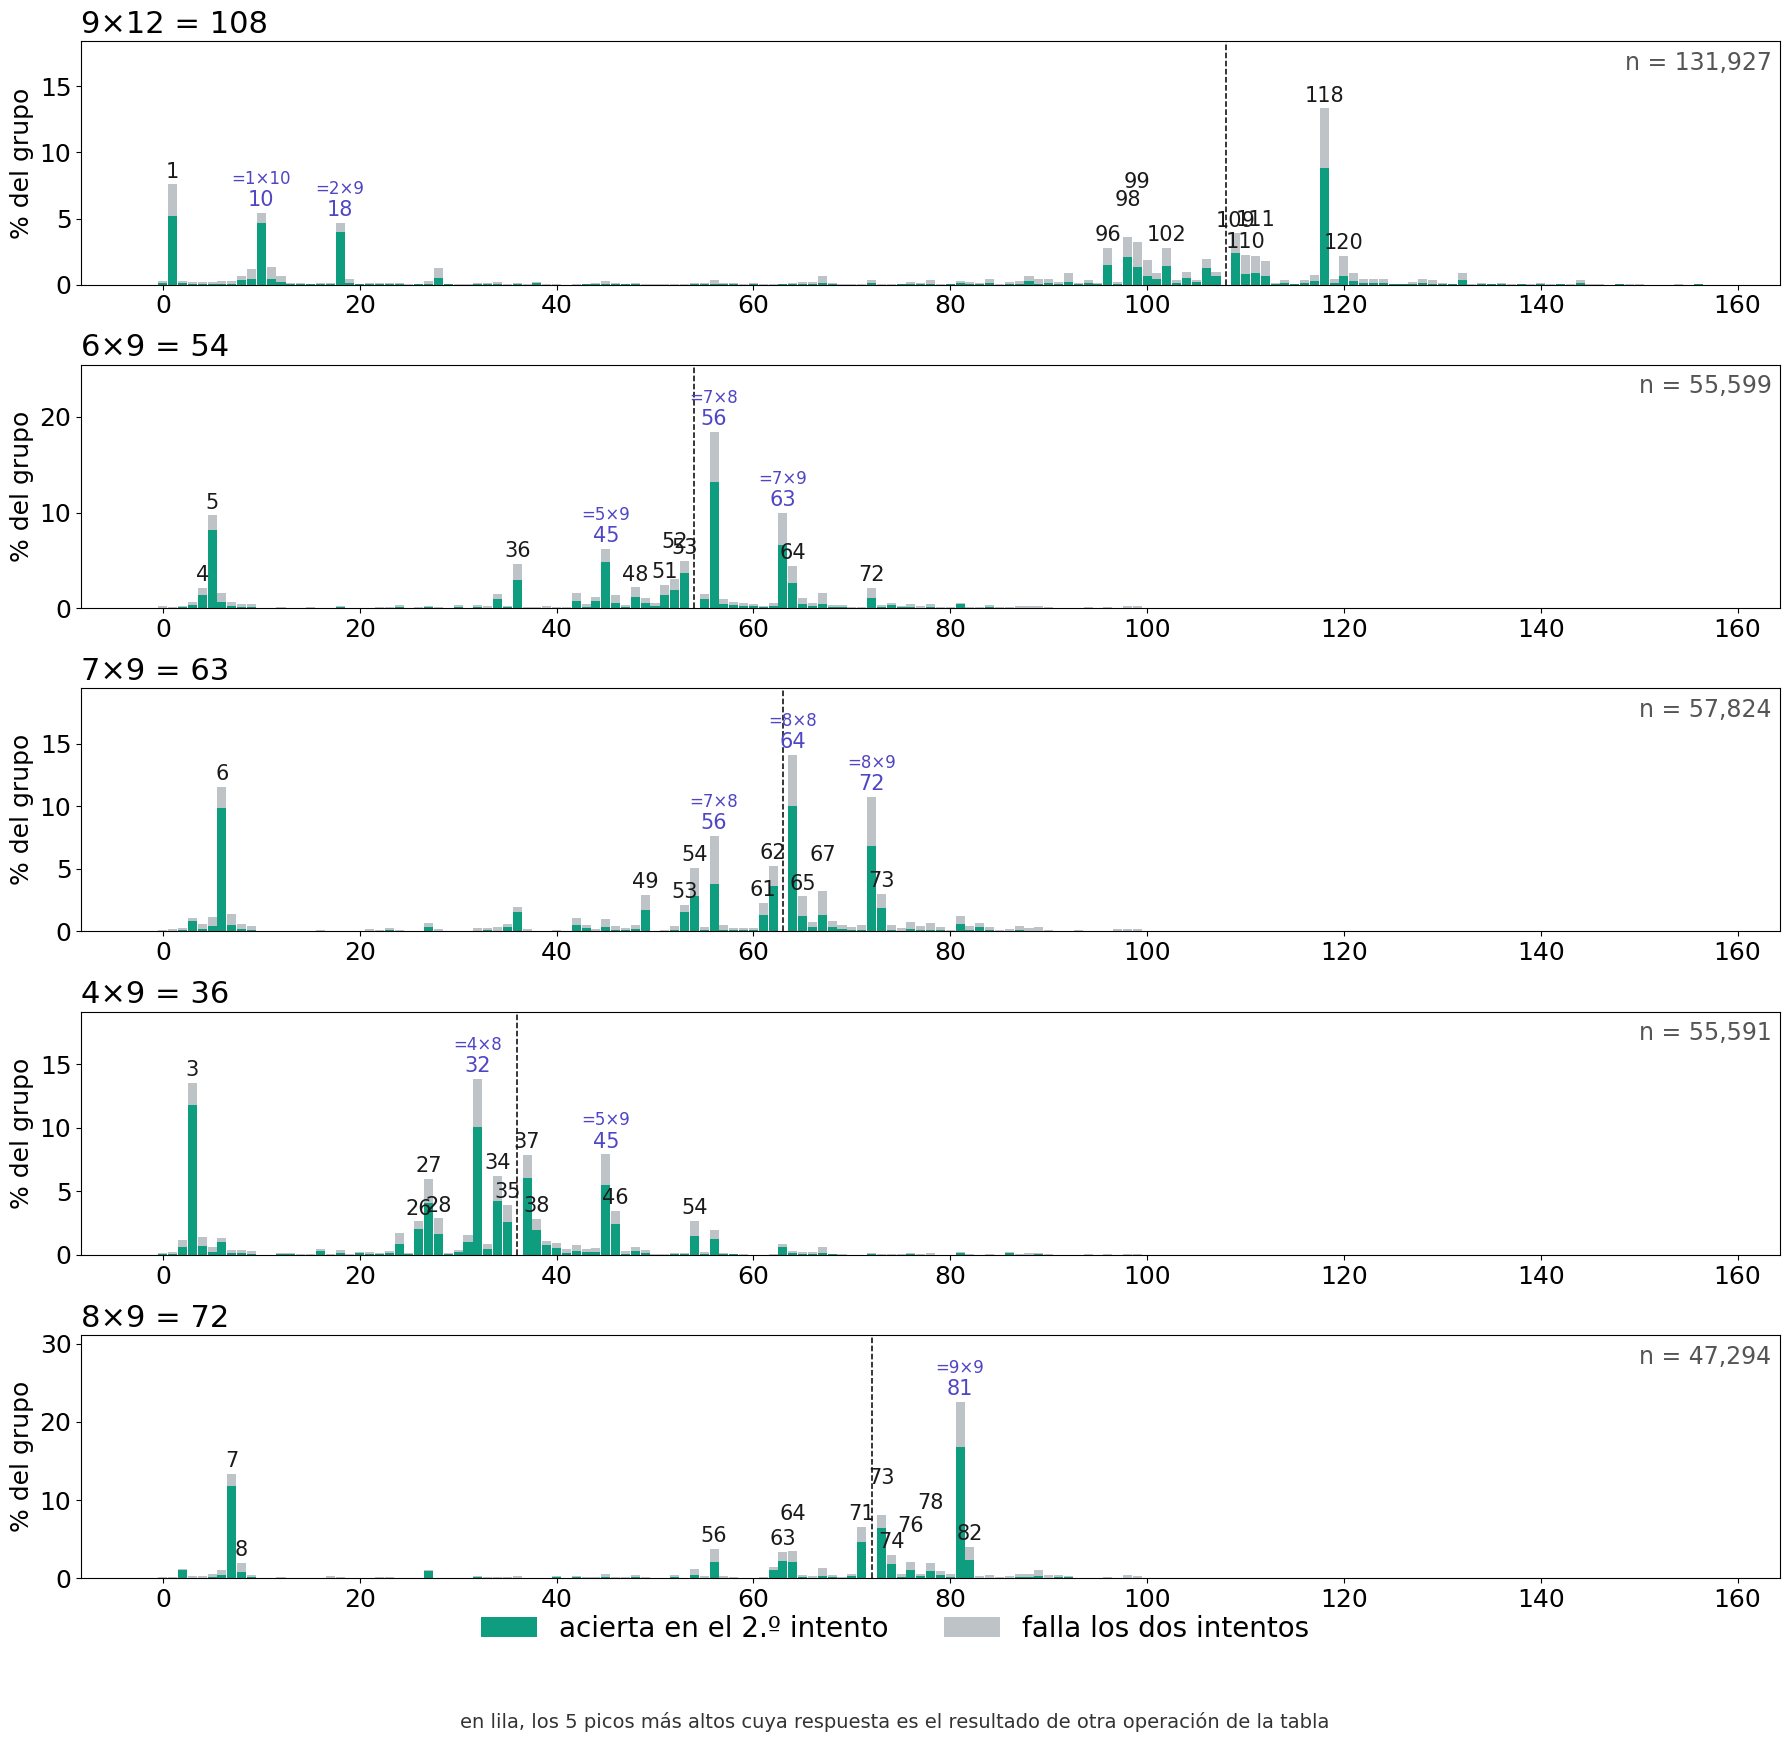

-> plots/fluency_nine_errors_attempt1_ages09_11.png / .pdf


In [8]:
# --- FLUENCY: the errors of the NINE TIMES TABLE ---------------------------
# Asked for by Maria (2026-08-25). It is the same figure as the one of the 5
# hard facts above: Fluency, 1st attempt, grades of POOL_AGES merged, bar split
# GREEN/GREY depending on whether the card is got right at the 2nd attempt,
# purple labels on the peaks that are the product of another fact. The only
# thing that changes are the facts: the nine table instead of the 5 of A998.
#
# WHY FLUENCY AND NOT A998: because the green only exists here. A998 gives one
# answer per item and has no second attempt, so there is nothing to split (which
# is why the zero cell is single-coloured), and on top of that its two-digit
# answers arrive cut keystroke by keystroke (Decision #11). Fluency is
# Leitner-style cards with two attempts and no clock, which is exactly what the
# colour code means: green = a slip that corrects itself, grey = the fact is not
# there.
#
# NO NEW QUERY IS NEEDED. fluency_hardest_facts_error_answers.sql already
# carries the {FACTS} marker, so this cell runs it again with the facts of the
# nine table. cached_query() hashes the TEXT executed, not the file name, so
# this is a cache miss the first time and afterwards it lives in its own
# .parquet without touching the one of the figure above.
# EVERYTHING GOES INTO VARIABLES WITH SUFFIX 9 (err9, plot9, facts9): if they
# overwrote err / plot / facts, the cells above would be left looking at
# different data without saying so, which is the silent way to get this wrong.
#
# WHICH FACTS: the whole nine table that Fluency drills, 1x9 up to 12x9 -- this
# app goes to 12 and A998 does not, so 9x10, 9x11 and 9x12 are here and have no
# equivalent in the other figure. The full table of 12 is printed, sorted by the
# app's own ranking, and the top NINE_TOP_N are drawn, so that the cut is
# visible instead of implicit.
#
# WATCH OUT FOR 9x12 = 108: it is the only fact here with a THREE-digit product,
# and that breaks two things the figure above took for granted. First, the
# 'too_many_digits' rule of the .sql (`answer > 99 AND product <= 99`) never
# fires on this fact, so 4-digit junk was getting in: it is filtered again here
# with the general rule. Second, the axis cannot stay at 0-99. Both are
# commented in place further down.
FACTS_NINE = sorted({(min(a, 9), max(a, 9)) for a in range(1, 13)})
NINE_TOP_N = 5            # how many facts get drawn

sql9 = SQL_PATH.read_text(encoding="utf-8")
years9_sql = ", ".join(f"'{y}'" for y in YEARS)
sql9, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years9_sql})\\1", sql9)
assert n_y == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_y}"
facts9_sql = ", ".join(f"({lo}, {hi})" for lo, hi in FACTS_NINE)
sql9, n_f = re.subn(r"IN \([^\n]*\)(\s*-- \{FACTS\})", f"IN ({facts9_sql})\\1", sql9)
assert n_f == 1, f"Esperava 1 marcador -- {{FACTS}}, n'he trobat {n_f}"
sql9, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                    f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql9)
assert n_a == 1, f"Esperava 1 marcador -- {{AGES}}, n'he trobat {n_a}"

err9 = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql9)

facts9 = (err9.groupby(["lo", "hi", "product"], as_index=False)
              .agg(fluency_rank=("fluency_rank", "max"),
                   fluency_error_pct=("fluency_error_pct", "max"),
                   n_fact=("n_fact_all_ages", "max"))
              .sort_values("fluency_error_pct", ascending=False))

# Same check as the loading cell: a fact that returns no row would vanish from
# the figure without warning (see the note about the 6x4).
falten9 = set(FACTS_NINE) - set(zip(facts9["lo"], facts9["hi"]))
assert not falten9, f"aquests fets de la taula del 9 no tenen dades: {sorted(falten9)}"
# fluency_rank comes from a CTE with HAVING COUNT(*) >= 2000: if a fact does not
# reach it, it returns NULL, and failing here beats drawing it as if it ranked.
assert facts9["fluency_rank"].notna().all(), \
    ("algun fet de la taula del 9 no arriba als 2000 intents que demana el"
     " ranquing de la query: " +
     str(facts9.loc[facts9["fluency_rank"].isna(), ["lo", "hi"]].to_dict("records")))
facts9 = facts9.astype({"lo": int, "hi": int, "product": int, "fluency_rank": int})

print("FLUIDESA | tipus d'error a la TAULA DEL 9")
print(f"YEARS = {YEARS} | edats {AGE_MIN}-{AGE_MAX} | guessing rapid <1.2s exclos"
      " de les respostes errronies (mateix .sql que la figura de dalt)")
print("Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts")
print("      JOIN dwh_global_dimensions_historic.d_students per student_uuid")
print(f"Files: {len(err9):,} (fet x curs x intent x resposta) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print("\nLa taula del 9 dins de la dificultat de FLUIDESA (ranquing sobre TOTS")
print("els fets de l'app, no nomes aquests 12):")
print(facts9.assign(operacio=lambda d: d.lo.astype(str) + "×" + d.hi.astype(str)
                                       + " = " + d["product"].astype(str))
            [["operacio", "fluency_rank", "fluency_error_pct", "n_fact"]]
            .to_string(index=False))

# Same filter as cell 1: out of the drawing go the answers that have no place
# on a numeric axis (no answer, more digits than the product, or flagged wrong
# with the right answer). `fewer_digits` DOES go in: in Fluency it is a real
# answer, not a record cut short as in A998.
plot9 = err9[~err9["error_type"].isin(NOT_PLOTTED)].copy()

# user_answer can arrive NULL even when error_type is not 'no_answer': the .sql
# does a TRY_CAST to INT (2026-08-25, after a 10-digit answer blew up the sister
# A998 query), so an absurdly large numeric answer comes back as NULL instead of
# taking the query down. It has no place on the axis, but it is not a "no
# answer" either: it is counted and left out.
n_null9 = int(plot9.loc[plot9["user_answer"].isna(), "n"].sum())
if n_null9:
    print(f"AVIS: {n_null9:,} respostes numeriques no caben a un INT (TRY_CAST ->"
          " NULL) i queden fora de l'histograma")
plot9 = plot9[plot9["user_answer"].notna()].copy()
plot9["user_answer"] = plot9["user_answer"].astype(int)
assert (plot9["user_answer"] != plot9["product"]).all(), \
    "Hi ha barres justament al producte correcte"

# --- MORE DIGITS THAN THE PRODUCT, generalising the rule of the .sql -------
# The taxonomy in the .sql calls 'too_many_digits' "more digits than the
# product", but the condition actually written is `answer > 99 AND product <=
# 99`: it only holds for two-digit products, which is all the figure of the 5
# hard facts ever had. Not here: 9x12 = 108 has three and 1x9 = 9 has one, and
# in both the rule never fires. Measured on 2026-08-25 over this same cache:
#   9x12  3.6% of the "numeric answers" have 4+ digits -- 1088, 1234, 9999,
#         6767, 1111... 2,090 distinct values above 500.
#   1x9   63% have two or more digits.
# With the axis stretched to 156, this junk does not only make a mess: it moves
# the denominator of EVERY panel. The rule is applied again here, in its general
# form (more digits than the product), instead of expecting it from the .sql.
# The .sql is deliberately NOT touched: the figures above use it and changing it
# would invalidate their cache without changing any of their results (all their
# facts have two-digit products). If it is ever generalised there, this block
# can go.
ndig9 = plot9["product"].astype(int).astype(str).str.len()
massa9 = plot9["user_answer"] >= 10 ** ndig9
n_massa9 = int(plot9.loc[massa9, "n"].sum())
print(f"Fora per tenir mes xifres que el producte: {n_massa9:,} respostes"
      f" ({100 * n_massa9 / plot9['n'].sum():.2f}% de les numeriques)")
plot9 = plot9[~massa9].copy()

top9 = facts9.head(NINE_TOP_N)
print(f"\nEs dibuixen els {NINE_TOP_N} amb mes error:"
      f" {[f'{r.lo}×{r.hi}' for r in top9.itertuples()]}")

# AXIS CEILING. If every fact drawn has a two-digit product, the axis is the
# 0-99 of the figure above and nothing else is needed. If any has three digits
# (9x12 = 108), the axis reaches the largest product of the WHOLE Fluency table
# (12x12 = 144) plus one step (12): that way any answer that is itself a fact of
# the table fits, which is the criterion the purple marking uses. It is not a
# window chosen by eye.
# What stays above it does NOT disappear from the calculation: the denominator
# is still ALL the numeric answers of the fact, as in the ZOOM cells, so the
# heights stay comparable with the figure above. They are just not visible --
# and since this concentrates in ONE fact (the 9x12), the % is reported fact by
# fact below and not only in a total that would hide it.
ANSWER_MAX = 99 if top9["product"].max() <= 99 else TABLE_MAX * TABLE_MAX + TABLE_MAX
d9 = plot9[(plot9["attempt_no"] == 1)
           & (plot9["classroom_course_age"].isin(POOL_AGES))]
d9_top = d9.merge(top9[["lo", "hi"]], on=["lo", "hi"])
fora9 = d9_top.loc[d9_top["user_answer"] > ANSWER_MAX, "n"].sum()
print(f"Respostes per damunt de {ANSWER_MAX}: {int(fora9):,} de"
      f" {int(d9_top['n'].sum()):,} ({100 * fora9 / d9_top['n'].sum():.3f}%)"
      f" -- l'eix x va de 0 a {ANSWER_MAX}")

# n per fact and recovery: it is what the colour is explaining, so it is printed.
print("\nPer fet (1r intent, cursos fosos): respostes numeriques i % que"
      " s'encerta al 2n intent")
for r in top9.itertuples():
    d = d9_top[(d9_top["lo"] == r.lo) & (d9_top["hi"] == r.hi)]
    tot = d["n"].sum()
    rec = d.loc[d["recovered_at_second"] == 1, "n"].sum()
    fora = d.loc[d["user_answer"] > ANSWER_MAX, "n"].sum()
    print(f"  {r.lo}×{r.hi} = {r.product:>3}: n = {int(tot):>7,}"
          f" | recuperades al 2n intent {100 * rec / tot:5.1f}%"
          f" | fora de l'eix {100 * fora / tot:5.2f}%")
    assert tot >= MIN_CELL_ERRORS, \
        f"{r.lo}×{r.hi} te nomes {int(tot)} respostes numeriques: massa poques per un histograma"

fig, axes = plt.subplots(len(top9), 1, figsize=(FIG_W, PANEL_H * len(top9)),
                         squeeze=False)
for i, f in enumerate(top9.itertuples()):
    ax = axes[i][0]
    d = d9_top[(d9_top["lo"] == f.lo) & (d9_top["hi"] == f.hi)]
    tot = d["n"].sum()

    # Split bar: green for the part recovered at the 2nd attempt, grey for the
    # part that fails both. Exactly the same as plot_pooled.
    rec = (d[d["recovered_at_second"] == 1].groupby("user_answer")["n"].sum()
           .reindex(range(0, ANSWER_MAX + 1), fill_value=0))
    fai = (d[d["recovered_at_second"] == 0].groupby("user_answer")["n"].sum()
           .reindex(range(0, ANSWER_MAX + 1), fill_value=0))
    ax.bar(rec.index, 100 * rec / tot, width=0.92, color=COLOR_RECOVERED)
    ax.bar(fai.index, 100 * fai / tot, width=0.92, color=COLOR_FAILED,
           bottom=100 * rec / tot)
    height = 100 * (rec + fai) / tot

    ax.axvline(f.product, color="black", ls="--", lw=1.1)

    # Peak labels: same rule as plot_pooled (same count, same floor, same
    # collision handling, same purple), so both figures read the same way.
    # TABLE_MAX is still 12: here it really applies, because Fluency drills up
    # to 12.
    peaks = height[height >= ANNOT_FLOOR_PCT].nlargest(ANNOT_TOP_N).sort_index()
    marked = set(height.nlargest(MARK_TOP_N).index)
    same_height = (ANNOT_FONT + 4) / (PANEL_H * 72) * max(height.max(), 1e-9) * 1.3
    last_x, last_y, occupied = -99, 0.0, 0
    for x, y in peaks.items():
        collides = (x - last_x <= 2) and (abs(y - last_y) < same_height)
        level = occupied if collides else 0
        dy = 2 + level * (ANNOT_FONT + 2)

        truncada = x < 10 <= f.product        # half-typed answer, not a calculation
        pair = (other_fact(int(x), f.lo, f.hi)
                if (x in marked and not truncada) else None)
        color = COL_MARK if pair is not None else COL_PLAIN

        ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, dy),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=ANNOT_FONT, color=color)
        if pair is not None:
            ax.annotate(f"={pair[0]}×{pair[1]}", xy=(x, y),
                        xytext=(0, dy + ANNOT_FONT + 1),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=ANNOT_FONT - 3, color=color)
        last_x, last_y = x, y
        occupied = level + (2 if pair is not None else 1)

    ax.set_ymargin(0.38)
    ax.autoscale_view()
    ax.set_ylim(bottom=0)
    ax.set_title(f"{f.lo}×{f.hi} = {f.product}", fontsize=FONT_BASE, loc="left")
    ax.set_ylabel("% del grupo", fontsize=FONT_BASE - 4)
    ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)
    ax.annotate(f"n = {int(tot):,}", xy=(0.995, 0.96), xycoords="axes fraction",
                ha="right", va="top", fontsize=FONT_BASE - 5, color="#555555")

fig.legend(handles=[Patch(facecolor=COLOR_RECOVERED, label="acierta en el 2.º intento"),
                    Patch(facecolor=COLOR_FAILED, label="falla los dos intentos")],
           loc="lower center", ncol=2, frameon=False, fontsize=FONT_BASE - 2,
           bbox_to_anchor=(0.5, -0.004))
fig.text(0.5, -0.030,
         f"en lila, los {MARK_TOP_N} picos más altos cuya respuesta es el"
         " resultado de otra operación de la tabla",
         ha="center", va="top", fontsize=ANNOT_FONT - 1, color="#333333")
fig.tight_layout(rect=(0, 0.02, 1, 0.98))
out = (HERE / "plots"
       / f"fluency_nine_errors_attempt1_ages{POOL_AGES[0]:02d}_{POOL_AGES[-1]:02d}")
fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(f"-> plots/{out.name}.png / .pdf")


FLUIDESA | tipus d'error als QUADRATS (1×1 ... 12×12)
YEARS = ['ES_2025'] | edats 8-15 | guessing rapid <1.2s exclos de les respostes errronies (mateix .sql que les figures de dalt)
Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts
      JOIN dwh_global_dimensions_historic.d_students per student_uuid
Files: 26,840 (fet x curs x intent x resposta) | cache -> descriptive\cache/

Els quadrats dins de la dificultat de FLUIDESA (ranquing sobre TOTS els
fets de l'app, no nomes aquests 12):
   operacio  fluency_rank  fluency_error_pct  n_fact
12×12 = 144             1             62.478  291191
11×11 = 121             2             59.712  267949
   8×8 = 64             7             39.265  281313
   7×7 = 49            15             29.490  198640
   6×6 = 36            26             20.548  200996
   4×4 = 16            30             18.775  248612
   9×9 = 81            37             12.074  170627
   5×5 = 25            40             10.442  196876
10×10 = 100   

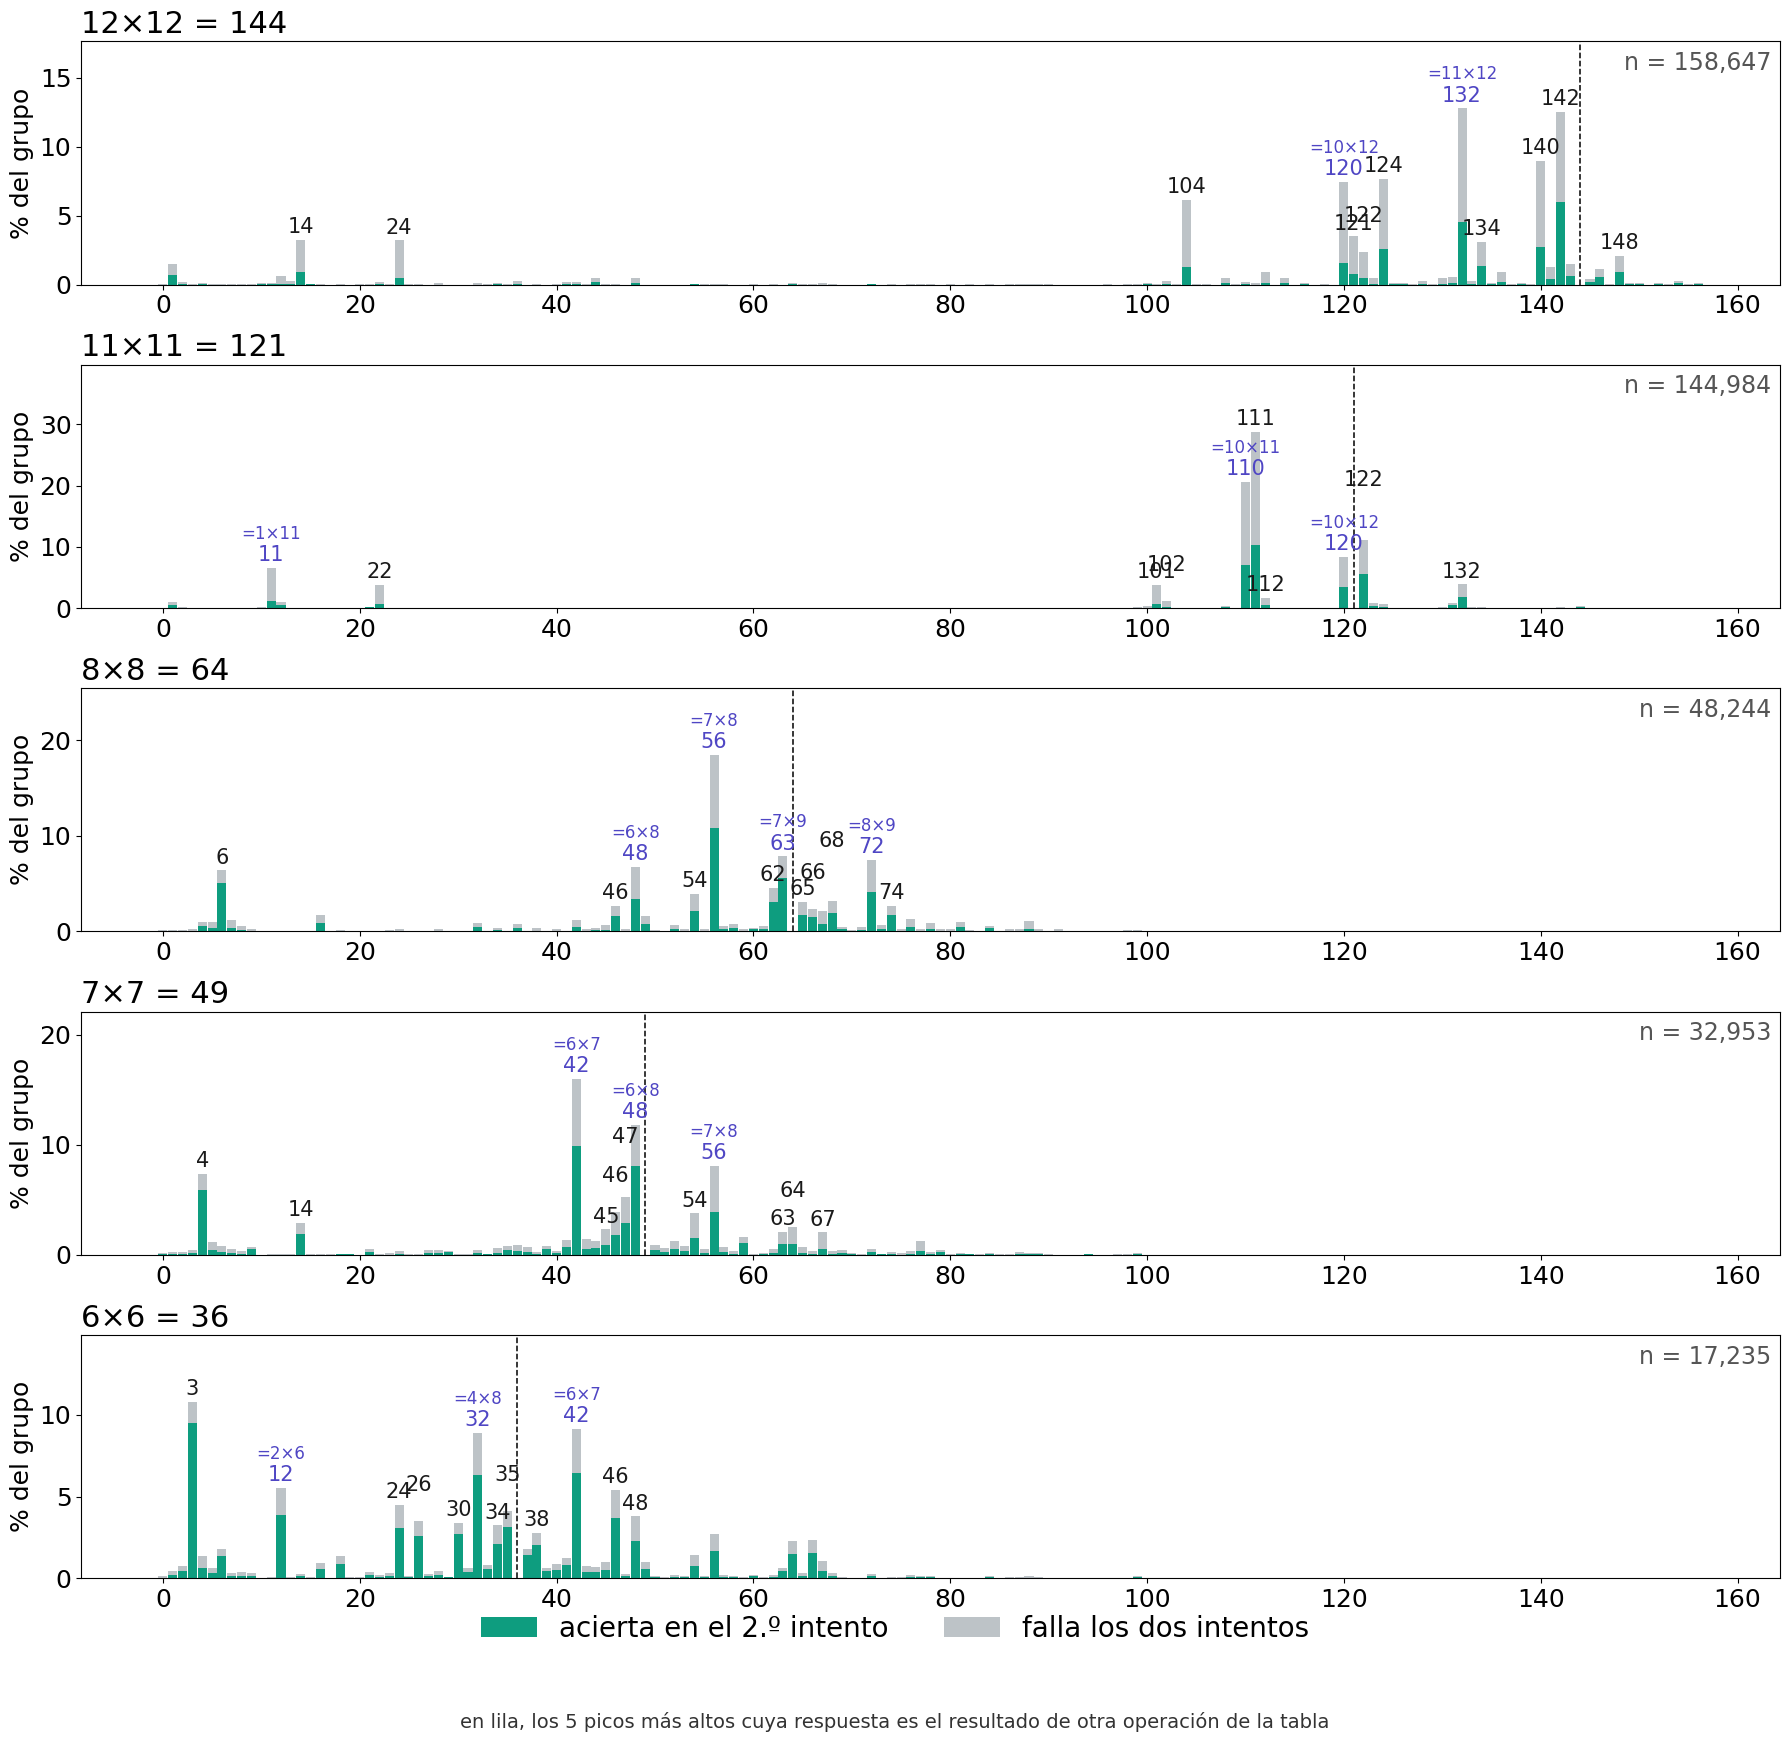

-> plots/fluency_square_errors_attempt1_ages09_11.png / .pdf


In [9]:
# --- FLUENCY: the errors of the SQUARES ------------------------------------
# Asked for by Maria (2026-08-25). Same figure as the nine table just above,
# changing only the set of facts: the squares 1x1 ... 12x12. Everything else is
# identical and is not explained again here -- Fluency, 1st attempt, grades of
# POOL_AGES merged, bar split GREEN/GREY depending on whether the card is got
# right at the 2nd attempt, purple labels on the peaks that are the product of
# another fact, and the same query with the {FACTS} marker rewritten. If you
# change a convention, change it in both cells.
#
# VARIABLES WITH SUFFIX SQ for the same reason the nine-table cell uses 9: they
# must not overwrite err / plot / facts (the figure of the 5 hard facts) nor
# err9 / plot9 / facts9 (the nine table).
#
# WHY THE SQUARES ARE AN INTERESTING SET and not just 12 arbitrary facts: they
# are the only group where both factors move at once. In the nine table the
# natural neighbour of an error is 9x(n+-1), which changes the product by 9; in
# a square n x n the neighbours are n x (n+-1), i.e. +-n, and the next square is
# at (n+1)^2 = n^2 + 2n + 1. The figure should show whether the wrong answers
# fall on the neighbouring rectangles or on the neighbouring square, which are
# two different things. It is not taken on trust: it is read off the drawing.
#
# CAREFUL: there are MORE facts with a product outside two digits here than in
# the nine table -- 1x1, 2x2 and 3x3 have one, and 10x10 = 100, 11x11 = 121 and
# 12x12 = 144 have three. Both ends break the 'too_many_digits' rule of the
# .sql, which is written for two-digit products only (`answer > 99 AND product
# <= 99`) and therefore never fires at either end. It is filtered again here
# with the general version, as in the nine-table cell, and the axis follows the
# same rule as there.
FACTS_SQ = [(a, a) for a in range(1, 13)]
SQ_TOP_N = 5              # how many squares get drawn

sqsql = SQL_PATH.read_text(encoding="utf-8")
years_sq = ", ".join(f"'{y}'" for y in YEARS)
sqsql, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sq})\\1", sqsql)
assert n_y == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_y}"
facts_sq_sql = ", ".join(f"({lo}, {hi})" for lo, hi in FACTS_SQ)
sqsql, n_f = re.subn(r"IN \([^\n]*\)(\s*-- \{FACTS\})", f"IN ({facts_sq_sql})\\1", sqsql)
assert n_f == 1, f"Esperava 1 marcador -- {{FACTS}}, n'he trobat {n_f}"
sqsql, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                     f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sqsql)
assert n_a == 1, f"Esperava 1 marcador -- {{AGES}}, n'he trobat {n_a}"

errsq = cached_query(SQL_PATH, CACHE_DIR, sql_text=sqsql)

factssq = (errsq.groupby(["lo", "hi", "product"], as_index=False)
                .agg(fluency_rank=("fluency_rank", "max"),
                     fluency_error_pct=("fluency_error_pct", "max"),
                     n_fact=("n_fact_all_ages", "max"))
                .sort_values("fluency_error_pct", ascending=False))

faltensq = set(FACTS_SQ) - set(zip(factssq["lo"], factssq["hi"]))
assert not faltensq, f"aquests quadrats no tenen dades: {sorted(faltensq)}"
assert factssq["fluency_rank"].notna().all(), \
    ("algun quadrat no arriba als 2000 intents que demana el ranquing de la"
     " query: " + str(factssq.loc[factssq["fluency_rank"].isna(),
                                  ["lo", "hi"]].to_dict("records")))
factssq = factssq.astype({"lo": int, "hi": int, "product": int, "fluency_rank": int})

print("FLUIDESA | tipus d'error als QUADRATS (1×1 ... 12×12)")
print(f"YEARS = {YEARS} | edats {AGE_MIN}-{AGE_MAX} | guessing rapid <1.2s exclos"
      " de les respostes errronies (mateix .sql que les figures de dalt)")
print("Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts")
print("      JOIN dwh_global_dimensions_historic.d_students per student_uuid")
print(f"Files: {len(errsq):,} (fet x curs x intent x resposta) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print("\nEls quadrats dins de la dificultat de FLUIDESA (ranquing sobre TOTS els")
print("fets de l'app, no nomes aquests 12):")
print(factssq.assign(operacio=lambda d: d.lo.astype(str) + "×" + d.hi.astype(str)
                                        + " = " + d["product"].astype(str))
             [["operacio", "fluency_rank", "fluency_error_pct", "n_fact"]]
             .to_string(index=False))

plotsq = errsq[~errsq["error_type"].isin(NOT_PLOTTED)].copy()
n_nullsq = int(plotsq.loc[plotsq["user_answer"].isna(), "n"].sum())
if n_nullsq:
    print(f"AVIS: {n_nullsq:,} respostes numeriques no caben a un INT (TRY_CAST ->"
          " NULL) i queden fora de l'histograma")
plotsq = plotsq[plotsq["user_answer"].notna()].copy()
plotsq["user_answer"] = plotsq["user_answer"].astype(int)
assert (plotsq["user_answer"] != plotsq["product"]).all(), \
    "Hi ha barres justament al producte correcte"

# More digits than the product, with the general rule (see the nine-table cell
# for why the .sql cannot do this as written). It weighs more here than there:
# in the small squares (1x1 = 1, 2x2 = 4, 3x3 = 9) any two-digit answer already
# has too many, and without this filter they would enter both the histogram and
# the denominator.
ndigsq = plotsq["product"].astype(int).astype(str).str.len()
massasq = plotsq["user_answer"] >= 10 ** ndigsq
n_massasq = int(plotsq.loc[massasq, "n"].sum())
print(f"Fora per tenir mes xifres que el producte: {n_massasq:,} respostes"
      f" ({100 * n_massasq / plotsq['n'].sum():.2f}% de les numeriques)")
plotsq = plotsq[~massasq].copy()

topsq = factssq.head(SQ_TOP_N)
print(f"\nEs dibuixen els {SQ_TOP_N} amb mes error:"
      f" {[f'{r.lo}×{r.hi}' for r in topsq.itertuples()]}")

# Same criterion as the nine-table cell: 0-99 if every product drawn has two
# digits, and otherwise up to the largest product of the table (12x12 = 144)
# plus one step, which is what makes any answer that is itself a fact fit. The
# denominator is still all the numeric answers of the fact.
ANSWER_MAX_SQ = 99 if topsq["product"].max() <= 99 else TABLE_MAX * TABLE_MAX + TABLE_MAX
dsq = plotsq[(plotsq["attempt_no"] == 1)
             & (plotsq["classroom_course_age"].isin(POOL_AGES))]
dsq_top = dsq.merge(topsq[["lo", "hi"]], on=["lo", "hi"])
forasq = dsq_top.loc[dsq_top["user_answer"] > ANSWER_MAX_SQ, "n"].sum()
print(f"Respostes per damunt de {ANSWER_MAX_SQ}: {int(forasq):,} de"
      f" {int(dsq_top['n'].sum()):,} ({100 * forasq / dsq_top['n'].sum():.3f}%)"
      f" -- l'eix x va de 0 a {ANSWER_MAX_SQ}")

# n, recovery, and the two answers the structure of a square makes you expect:
# the neighbouring rectangle n*(n-1) = n^2 - n and the next square (n+1)^2 =
# n^2 + 2n + 1. Printed because the drawing is dense and these two figures are
# the reading.
print("\nPer quadrat (1r intent, cursos fosos): n, recuperacio, i el pes dels"
      " dos veins previsibles")
for r in topsq.itertuples():
    d = dsq_top[(dsq_top["lo"] == r.lo) & (dsq_top["hi"] == r.hi)]
    tot = d["n"].sum()
    rec = d.loc[d["recovered_at_second"] == 1, "n"].sum()
    n = r.lo
    rect = d.loc[d["user_answer"].isin([n * (n - 1), n * (n + 1)]), "n"].sum()
    seguent = d.loc[d["user_answer"].isin([(n - 1) ** 2, (n + 1) ** 2]), "n"].sum()
    fora = d.loc[d["user_answer"] > ANSWER_MAX_SQ, "n"].sum()
    print(f"  {r.lo}×{r.hi} = {r.product:>3}: n = {int(tot):>7,}"
          f" | recuperades {100 * rec / tot:5.1f}%"
          f" | fora de l'eix {100 * fora / tot:5.2f}%"
          f" | rectangle vei ({n * (n - 1)}/{n * (n + 1)}) {100 * rect / tot:5.2f}%"
          f" | quadrat vei ({(n - 1) ** 2}/{(n + 1) ** 2}) {100 * seguent / tot:5.2f}%")
    assert tot >= MIN_CELL_ERRORS, \
        f"{r.lo}×{r.hi} te nomes {int(tot)} respostes numeriques: massa poques per un histograma"

fig, axes = plt.subplots(len(topsq), 1, figsize=(FIG_W, PANEL_H * len(topsq)),
                         squeeze=False)
for i, f in enumerate(topsq.itertuples()):
    ax = axes[i][0]
    d = dsq_top[(dsq_top["lo"] == f.lo) & (dsq_top["hi"] == f.hi)]
    tot = d["n"].sum()

    rec = (d[d["recovered_at_second"] == 1].groupby("user_answer")["n"].sum()
           .reindex(range(0, ANSWER_MAX_SQ + 1), fill_value=0))
    fai = (d[d["recovered_at_second"] == 0].groupby("user_answer")["n"].sum()
           .reindex(range(0, ANSWER_MAX_SQ + 1), fill_value=0))
    ax.bar(rec.index, 100 * rec / tot, width=0.92, color=COLOR_RECOVERED)
    ax.bar(fai.index, 100 * fai / tot, width=0.92, color=COLOR_FAILED,
           bottom=100 * rec / tot)
    height = 100 * (rec + fai) / tot

    ax.axvline(f.product, color="black", ls="--", lw=1.1)

    peaks = height[height >= ANNOT_FLOOR_PCT].nlargest(ANNOT_TOP_N).sort_index()
    marked = set(height.nlargest(MARK_TOP_N).index)
    same_height = (ANNOT_FONT + 4) / (PANEL_H * 72) * max(height.max(), 1e-9) * 1.3
    last_x, last_y, occupied = -99, 0.0, 0
    for x, y in peaks.items():
        collides = (x - last_x <= 2) and (abs(y - last_y) < same_height)
        level = occupied if collides else 0
        dy = 2 + level * (ANNOT_FONT + 2)

        truncada = x < 10 <= f.product        # half-typed answer, not a calculation
        pair = (other_fact(int(x), f.lo, f.hi)
                if (x in marked and not truncada) else None)
        color = COL_MARK if pair is not None else COL_PLAIN

        ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, dy),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=ANNOT_FONT, color=color)
        if pair is not None:
            ax.annotate(f"={pair[0]}×{pair[1]}", xy=(x, y),
                        xytext=(0, dy + ANNOT_FONT + 1),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=ANNOT_FONT - 3, color=color)
        last_x, last_y = x, y
        occupied = level + (2 if pair is not None else 1)

    ax.set_ymargin(0.38)
    ax.autoscale_view()
    ax.set_ylim(bottom=0)
    ax.set_title(f"{f.lo}×{f.hi} = {f.product}", fontsize=FONT_BASE, loc="left")
    ax.set_ylabel("% del grupo", fontsize=FONT_BASE - 4)
    ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)
    ax.annotate(f"n = {int(tot):,}", xy=(0.995, 0.96), xycoords="axes fraction",
                ha="right", va="top", fontsize=FONT_BASE - 5, color="#555555")

fig.legend(handles=[Patch(facecolor=COLOR_RECOVERED, label="acierta en el 2.º intento"),
                    Patch(facecolor=COLOR_FAILED, label="falla los dos intentos")],
           loc="lower center", ncol=2, frameon=False, fontsize=FONT_BASE - 2,
           bbox_to_anchor=(0.5, -0.004))
fig.text(0.5, -0.030,
         f"en lila, los {MARK_TOP_N} picos más altos cuya respuesta es el"
         " resultado de otra operación de la tabla",
         ha="center", va="top", fontsize=ANNOT_FONT - 1, color="#333333")
fig.tight_layout(rect=(0, 0.02, 1, 0.98))
out = (HERE / "plots"
       / f"fluency_square_errors_attempt1_ages{POOL_AGES[0]:02d}_{POOL_AGES[-1]:02d}")
fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(f"-> plots/{out.name}.png / .pdf")


FLUIDESA | 6×8 = 48 | intent 1 | un panell per curs: [8, 9, 10, 11]
  dificultat dins de Fluidesa: 5e fet, 39.55% d'error (tots els cursos)
  curs                 n numeric   % del total   % recuperat al 2n   % error de la casella
      3.º (8 anys)      33,835        26.3%              44.2%                 50.48%
      4.º (9 anys)      31,786        24.7%              52.7%                 37.25%
      5.º (10 anys)      29,778        23.1%              58.7%                 38.64%
      6.º (11 anys)      33,475        26.0%              62.7%                 35.09%

  % DINS de cada curs de les 8 respostes mes frequents:
             8      9     10     11                              que es
resposta                                                               
56        8.28  10.58  11.82  11.61                               = 7×8
42        4.78  10.27  12.00  13.63                               = 6×7
46        6.91   8.54   9.32   8.84                 cap fet de la taula
4     

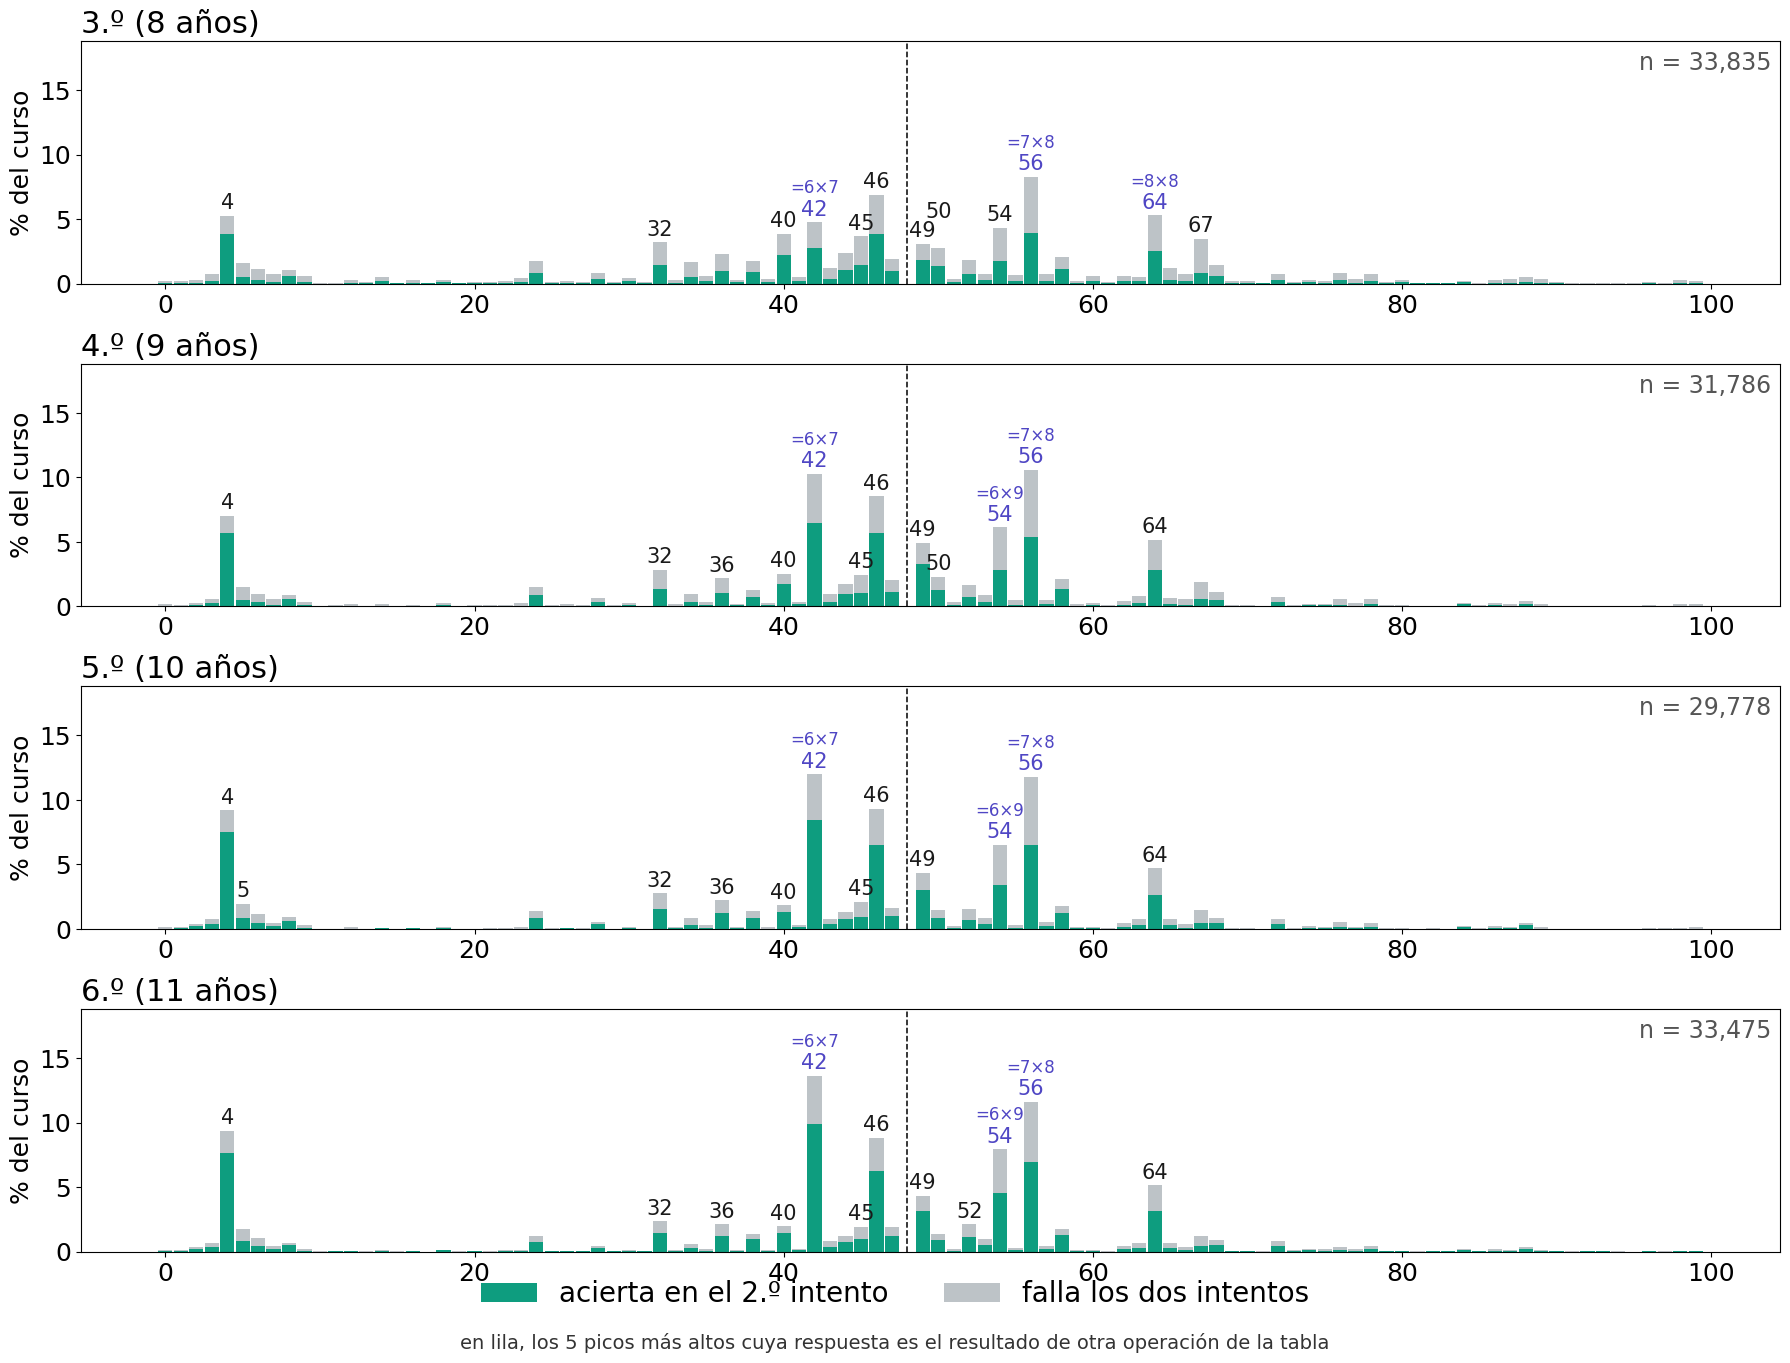

-> plots/fluency_errors_6x8_by_age_attempt1_ages08_11.png


In [10]:
# --- 6x8 GRADE BY GRADE ------------------------------------------------------
# Asked for by Maria (2026-08-24). The 5-panel figure and the 6x4 one merge
# grades 4th-6th and leave the 8-year-olds out; here it is the other way round:
# ONLY 6x8 (the fact with the most error in Fluency, 39.55%) and ONE PANEL PER
# GRADE, with the 8-year-olds included. It is the figure that shows what the
# collapsed one hides by construction -- whether the answer profile moves with
# age or not.
#
# THE 8-YEAR-OLDS ARE HERE ON PURPOSE. In the collapsed-figure cell the cosine
# similarity leaves 3rd out of the merged group (0.858-0.949 against any other
# grade, against 0.984-0.999 among 4th, 5th and 6th). That number says it
# canNOT be merged with the others, not that it cannot be looked at: here it
# gets its own panel and you can see how it differs.
#
# EACH PANEL IS NORMALISED TO ITS OWN GRADE: the denominator is ALL the numeric
# answers to 6x8 of that grade and that attempt. The grades have very different
# n (printed below), so the % within the grade is the only reading comparable
# across panels; the absolute n would not be.
# The y axis is SHARED (sharey) because the comparison between grades is
# precisely one of heights; the x axis is the full 0-99 and has no limits, as
# the project rule says (2026-07-20) -- the ZOOM cells above are the exception,
# not this one.
#
# WHAT COMES OUT (measured on 2026-08-24 over the current cache, ES_2025, 1st
# attempt):
#   . the error rate of the cell falls with the grade -- 50.5% at 8 years and
#     then 37.3% / 38.6% / 35.1%. The big jump is 3rd to 4th, not 4th to 6th.
#   . the 42 (= 6x7, the table neighbour) almost triples: 4.8% of the errors in
#     3rd and 13.6% in 6th. The 56 (= 7x8) also rises (8.3% -> 11.6%) and so
#     does the 54 (= 6x9) (4.3% -> 7.9%).
#   . the 46 -- which is NOT a fact of the table -- stays flat (6.9% -> 8.8%)
#     and so does the 64 (5.3% -> 5.1%).
#   . recovery at the 2nd attempt rises with the grade: 44.2% in 3rd, 52.7%,
#     58.7% and 62.7% in 6th (the green part of each bar).
#   So: the older they are, the more their errors concentrate on neighbouring
#   facts of the table and the more they fix them on their own. This is a
#   description of the data as it is, not a statistical test.
#
# The rest is identical to the other figures: 1st attempt, bar split by whether
# the card is got right at the 2nd attempt, same colours, and a purple label on
# the MARK_TOP_N highest peaks when the answer is the product of another fact of
# the table (one-digit answers never get an operation: they are the tens digit
# of the product sent half typed, not a calculation).
FACT_BY_AGE = (6, 8)                  # in any order: it is normalised to (6, 8)
AGES_PANELS = AGES                    # [8, 9, 10, 11]; already filtered by MIN_CELL_ERRORS
GRADE = {8: "3.º", 9: "4.º", 10: "5.º", 11: "6.º", 12: "1.º ESO"}   # d_courses
N_TOP_TABLE = 8                       # rows of the per-grade comparison table


def _annotate_peaks(ax, height, lo, hi, product, panel_h, annot_font):
    """Peak labels with the same anti-overlap rule as the rest of the notebook:
    only the one that would really collide goes up a level (peaks <=2 units
    apart AND at similar heights), and it counts two lines if its neighbour
    carries the operation."""
    peaks = height[height >= ANNOT_FLOOR_PCT].nlargest(ANNOT_TOP_N).sort_index()
    marked = set(height.nlargest(MARK_TOP_N).index)
    same_height = (annot_font + 4) / (panel_h * 72) * max(height.max(), 1e-9) * 1.3
    last_x, last_y, occupied = -99, 0.0, 0
    for x, y in peaks.items():
        collides = (x - last_x <= 2) and (abs(y - last_y) < same_height)
        level = occupied if collides else 0
        dy = 2 + level * (annot_font + 2)

        truncada = x < 10 <= product          # half-typed answer, not a calculation
        pair = (other_fact(int(x), lo, hi) if (x in marked and not truncada) else None)
        color = COL_MARK if pair is not None else COL_PLAIN

        ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, dy), textcoords="offset points",
                    ha="center", va="bottom", fontsize=annot_font, color=color)
        if pair is not None:
            ax.annotate(f"={pair[0]}×{pair[1]}", xy=(x, y),
                        xytext=(0, dy + annot_font + 1), textcoords="offset points",
                        ha="center", va="bottom", fontsize=annot_font - 3, color=color)
        last_x, last_y = x, y
        occupied = level + (2 if pair is not None else 1)


def plot_fact_by_age(fact):
    """One panel per grade with the answer histogram of a SINGLE operation."""
    lo, hi = min(fact), max(fact)
    sel = facts[(facts["lo"] == lo) & (facts["hi"] == hi)]
    assert len(sel) == 1, f"{lo}×{hi} no surt a `facts` -- FACTS = {FACTS}"
    f = next(sel.itertuples())
    ages = list(AGES_PANELS)

    d_all = plot[(plot["attempt_no"] == ATTEMPT_NO)
                 & (plot["lo"] == lo) & (plot["hi"] == hi)
                 & (plot["classroom_course_age"].isin(ages))]

    # What will be seen, written down before drawing it.
    print(f"FLUIDESA | {lo}×{hi} = {f.product} | intent {ATTEMPT_NO}"
          f" | un panell per curs: {ages}")
    print(f"  dificultat dins de Fluidesa: {f.fluency_rank}e fet,"
          f" {float(f.fluency_error_pct):.2f}% d'error (tots els cursos)")
    print("  curs                 n numeric   % del total   % recuperat al 2n"
          "   % error de la casella")
    heights, totals, recs, errs = {}, {}, {}, {}
    for a in ages:
        d = d_all[d_all["classroom_course_age"] == a]
        tot = int(d["n"].sum())
        assert tot >= MIN_CELL_ERRORS, (
            f"{a} anys: nomes {tot} respostes numeriques (< MIN_CELL_ERRORS)"
            " -- l'histograma seria soroll")
        rec = (d[d["recovered_at_second"] == 1].groupby("user_answer")["n"].sum()
               .reindex(range(100), fill_value=0))
        fai = (d[d["recovered_at_second"] == 0].groupby("user_answer")["n"].sum()
               .reindex(range(100), fill_value=0))
        heights[a] = (100 * rec / tot, 100 * fai / tot)
        totals[a] = tot
        recs[a] = 100 * rec.sum() / tot
        # error_pct_first_cell comes repeated on every row of the cell (fact x grade)
        errs[a] = float(err.loc[(err["lo"] == lo) & (err["hi"] == hi)
                                & (err["classroom_course_age"] == a),
                                "error_pct_first_cell"].iloc[0])
    n_tot = sum(totals.values())
    for a in ages:
        print(f"  {GRADE.get(a, '?'):>7} ({a} anys)   {totals[a]:>9,}"
              f"   {100 * totals[a] / n_tot:>9.1f}%   {recs[a]:>15.1f}%"
              f"   {errs[a]:>19.2f}%")

    # The table that goes with the figure: the N_TOP_TABLE biggest answers
    # summing grades, and how much they weigh WITHIN each grade. It is the
    # numeric reading of whether the profile moves with age.
    pooled = (d_all.groupby("user_answer")["n"].sum()
              .reindex(range(100), fill_value=0))
    top_vals = [int(v) for v in pooled.nlargest(N_TOP_TABLE).index]
    tab = pd.DataFrame({a: (heights[a][0] + heights[a][1]).reindex(top_vals).to_numpy()
                        for a in ages}, index=top_vals)
    tab.index.name = "resposta"
    tab["que es"] = [
        (f"la desena de {f.product}, resposta a mitges" if v == f.product // 10
         else "una xifra sola, resposta a mitges") if v < 10 <= f.product
        else (lambda p: f"= {p[0]}×{p[1]}" if p else "cap fet de la taula")(other_fact(v, lo, hi))
        for v in top_vals]
    print(f"\n  % DINS de cada curs de les {N_TOP_TABLE} respostes mes frequents:")
    print(tab.round(2).to_string())

    fig, axes = plt.subplots(len(ages), 1, sharex=True, sharey=True, squeeze=False,
                             figsize=(FIG_W, PANEL_H * len(ages)))
    for i, a in enumerate(ages):
        ax = axes[i][0]
        rec, fai = heights[a]
        ax.bar(rec.index, rec, width=0.92, color=COLOR_RECOVERED)
        ax.bar(fai.index, fai, width=0.92, color=COLOR_FAILED, bottom=rec)
        ax.axvline(f.product, color="black", ls="--", lw=1.1)
        _annotate_peaks(ax, rec + fai, lo, hi, f.product, PANEL_H, ANNOT_FONT)

        ax.set_title(f"{GRADE.get(a, '?')} ({a} años)", fontsize=FONT_BASE, loc="left")
        ax.set_ylabel("% del curso", fontsize=FONT_BASE - 4)
        ax.tick_params(labelbottom=True, labelsize=FONT_BASE - 4)
        ax.annotate(f"n = {totals[a]:,}", xy=(0.995, 0.96), xycoords="axes fraction",
                    ha="right", va="top", fontsize=FONT_BASE - 5, color="#555555")

    # Room for the labels without pinning any ylim: the margin is an autoscale
    # one and, with sharey, it holds for all four panels at once.
    axes[0][0].set_ymargin(0.38)
    axes[0][0].autoscale_view()
    axes[0][0].set_ylim(bottom=0)

    fig.legend(handles=[Patch(facecolor=COLOR_RECOVERED, label="acierta en el 2.º intento"),
                        Patch(facecolor=COLOR_FAILED, label="falla los dos intentos")],
               loc="lower center", ncol=2, frameon=False,
               fontsize=FONT_BASE - 2, bbox_to_anchor=(0.5, -0.004))
    fig.text(0.5, -0.004,
             f"en lila, los {MARK_TOP_N} picos más altos cuya respuesta es el"
             " resultado de otra operación de la tabla",
             ha="center", va="top", fontsize=ANNOT_FONT - 1, color="#333333")
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))
    out = (HERE / "plots" / f"fluency_errors_{lo}x{hi}_by_age_attempt{ATTEMPT_NO}"
           f"_ages{ages[0]:02d}_{ages[-1]:02d}")
    fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
    plt.show()
    print(f"-> plots/{out.name}.png")


plot_fact_by_age(FACT_BY_AGE)
